In [945]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
from pathlib import Path
from scipy.interpolate import make_smoothing_spline
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from statsmodels.stats.multitest import multipletests

from collections import defaultdict, OrderedDict

# Load data

In [946]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO'
metabolomics_folder = data_folder / 'D_big_screen'
figure_folder = repo_folder / 'figures'/'3_big_screen'


In [947]:
normalization = 'TIC'
median_fn = metabolomics_folder / f'G_median_z_scores_{normalization}_norm_keio.csv'
df_data = pd.read_csv(median_fn)
df_data.rename(columns={'Z-score median': 'Median Z-score'}, inplace=True)

ionMz_annotation_fn = metabolomics_folder / 'H_ionMz_annotation.csv'
df_ionMz = pd.read_csv(ionMz_annotation_fn)
df_ionMz.drop_duplicates(subset=['ionMz'], inplace=True)

sample_metadata_fn = metabolomics_folder / 'I_sample_metadata_keio.csv'
df_sample_metadata = pd.read_csv(sample_metadata_fn)

auc_df = pd.read_csv(metabolomics_folder / 'J_auc_z_scores_keio.csv')

lam = 10
xval = 'AUC OD'
distance_fn = metabolomics_folder / f'K_timecurve_comparison_{normalization}_norm_lam_{lam}_{xval}.csv'
dis_df = pd.read_csv(distance_fn, index_col=0)


name_to_mz_fn = data_folder / 'Z_div/H_name_to_mz.csv'
name_to_mz_df = pd.read_csv(name_to_mz_fn)
name_to_mz_df['ionMz'] = name_to_mz_df.ionMz.str.split(';')
name_to_ionMz = {row['Name']: [float(x) for x in row['ionMz']] for _, row in name_to_mz_df.iterrows()}


In [948]:
df_mz = df_data.merge(df_ionMz, on='ionMz', how='left')
dis_mz = dis_df.merge(df_ionMz, on='ionMz', how='left')

In [949]:
df = df_mz.merge(df_sample_metadata, on=['Batch-Tube', 'Timepoint'], how='left')

In [950]:
df.sort_values(by=['Batch-Tube', 'ionMz', 'Hours'], inplace=True)

## Load OD data

In [951]:
od_fn = metabolomics_folder / 'B_od_data.csv'
od_df = pd.read_csv(od_fn, index_col=0)
od_df.sort_values(by = 'Strain', inplace = True)

# Drop slow strains

In [952]:
# Slow growing strains
drop_strains = ['dppB', 'tolC', 'ptsG',]
auc_df = auc_df[~auc_df.Strain.isin(drop_strains)]
dis_mz = dis_mz[~dis_mz.Strain.isin(drop_strains)]
df = df[~df.Strain.isin(drop_strains)]

In [953]:
max_pval = 0.005
min_effect = 3
sel_idx = (dis_mz['Rel. abs. distance'] > min_effect)&(dis_mz['p-value rel'] < max_pval)
sel_df = dis_mz.loc[sel_idx].copy()

# Positive effects

In [954]:
def plot_timecourse_difference(ax, df,batches, strains,ion_mz, xval='Hours', yval='Median Z-score', ystd='Z-score std'):
    data = df.loc[df.ionMz.isin(ionMz)&(df.Strain.isin(strains))&(df['Batch'].isin(batches))].copy()
    data.sort_values(by=['Strain', xval], inplace=True)

    for i, strain in enumerate(strains):
        strain_data = data.loc[data.Strain == strain].copy()
        is_duplicated = strain_data[xval].duplicated()
        if np.any(is_duplicated):
            strain_data.loc[is_duplicated, xval] += sorted([np.abs(x) for x in np.random.normal(0, 1e-2, size=is_duplicated.sum())])
        strain_data.sort_values(by = xval, inplace=True)
        x = strain_data[xval].values
        y = strain_data[yval].values
        y_std = strain_data[ystd].values
        spline = make_smoothing_spline(x, y, w = 1/y_std, lam = lam)
        xarr = np.linspace(x.min(), x.max(), 100, endpoint=True)
        
        ax.plot(xarr, spline(xarr), color=f'C{i}', zorder = 0)
        label = f'Δ${strain}$' if strain != 'WT' else 'WT'
        ax.scatter(x, y, color=f'C{i}', label=label, alpha = 0.5, edgecolor='k', s=50)
    
    
    # ax.set_title(f'Δ${strain}$ - m/z {ionMz:.3f} \n {row["Metabolite"]} ({row["KEGG"].replace(";"," / ")})', size = 10)
    # ax.set_xlabel('Time (hours)')
    # ax.set_ylabel('Median Z-score')
    # sns.despine()
    


    

In [955]:
# sel_df.sort_values(by=['Rel. abs. distance'], ascending=False).head(40)

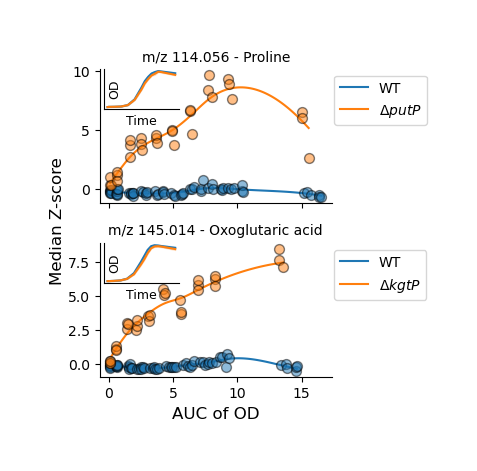

In [956]:
fig, axes = plt.subplots(2, 1, figsize=(3, 4), constrained_layout=False, sharex=True)
axes = axes.flatten()
data_to_plot = [
    ['putP','Proline', 2], 
    ['kgtP','Oxoglutaric acid', 5]
]
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    plot_timecourse_difference(axes[i], df, [batch], strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    axes[i].set_title(f'm/z {ionMz[0]:.3f} - {metabolite}', size = 10)

    # --- OD curve inset ---
    inset_ax = axes[i].inset_axes([0.02, 0.7, 0.32, 0.3])  # [x0, y0, width, height]
    od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin([batch])]
    l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain',hue_order = strains, ax = inset_ax)
    sns.despine(ax = inset_ax)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
    inset_ax.set_xlabel('Time', size = 9)
    # inset_ax.yaxis.set_label_position('right')
    # inset_ax.set_title('OD', fontsize=8)
    # inset_ax.legend(fontsize=6, loc='upper left', frameon=False)
    # inset_ax.get_legend_handles_labels()
    
    handles, labels = inset_ax.get_legend_handles_labels()
    labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
    legend = inset_ax.legend(handles, labels, fontsize=10, loc='upper left', frameon=True, ncol=1, bbox_to_anchor=[3,1])
    legend.set_title(None)  # Remove legend title
    

fig.supylabel('Median Z-score', x=-0.04, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    axes[-1].set_xlabel('Time [h]', size = 12)
else:
    axes[-1].set_xlabel('AUC of OD', size = 12)
sns.despine()
plt.subplots_adjust(hspace=0.3)
plt.savefig(figure_folder / f'figure_5_putP_kgtP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_putP_kgtP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

## Glutamate

In [957]:
df.loc[df.Strain.isin(['gltS', 'gltP', 'gadC', 'gltJ']), 'Batch'].unique()

array([2., 3., 4.])

In [958]:
dis_df.loc[dis_df.ionMz.isin(name_to_ionMz['Glutamic acid'])&(dis_df.Strain.isin(['gltP','gltS','gltJ','gadC']))]

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs
3517,gltJ,146.046,1.157707,0.017195,0.197374,0.002932,0.068799,0.272175,0.170487,gltJ,WT,0.022,0.108
7453,gltP,146.046,5.349006,5.182146,3.416001,3.309441,0.971343,0.305904,0.638624,gltP,WT,0.000,0.000
7945,gadC,146.046,2.170204,2.166315,0.855320,0.853787,0.482335,0.305904,0.394120,gadC,WT,0.000,0.000
12127,gltS,146.046,5.813300,5.813300,1.699339,1.699339,0.263067,0.321571,0.292319,gltS,WT,0.000,0.000


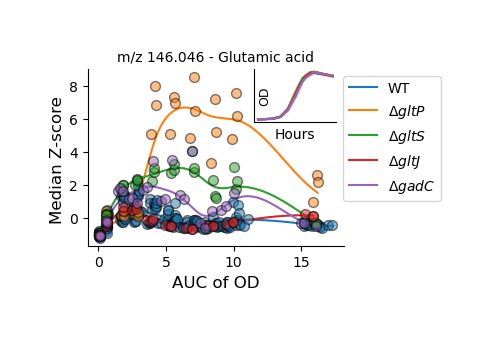

In [959]:
fig, ax = plt.subplots(1, 1, figsize=(4, 2.5), constrained_layout=False, sharex=True)
# axes = axes.flatten()
data_to_plot = [
    ['gltP;gltS;gltJ;gadC','Glutamic acid', [2,3,4]], 
]
yval = 'Median Z-score'
ystd = 'Z-score std'
for j, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    data = df.loc[df.ionMz.isin(ionMz)&(df.Strain.isin(strains))&(df['Batch'].isin(batch))].copy()
    data.sort_values(by=['Strain', xval], inplace=True)
    # plot_timecourse_difference(ax, df, [batch], strains, ionMz, xval='Hours', yval='Median Z-score', ystd='Z-score std')

    for i, strain in enumerate(strains):
        strain_data = data.loc[data.Strain == strain].copy()
        strain_data.sort_values(by=[xval], inplace=True)
        is_duplicated = strain_data[xval].duplicated()
        if np.any(is_duplicated):
            strain_data.loc[is_duplicated, xval] += sorted(np.random.normal(0, 1e-2, size=is_duplicated.sum()))
        strain_data.sort_values(by=xval, inplace=True)
        x = strain_data[xval].values
        y = strain_data[yval].values
        y_std = strain_data[ystd].values
        spline = make_smoothing_spline(x, y, w = 1/y_std, lam = lam)
        xarr = np.linspace(x.min(), x.max(), 100, endpoint=True)
        
        ax.plot(xarr, spline(xarr), color=f'C{i}', zorder = 0)
        label = f'Δ${strain}$' if strain != 'WT' else 'WT'

        ax.scatter(x, y, color=f'C{i}', label=label, alpha = 0.5, edgecolor='k', s=50)


    inset_ax = ax.inset_axes([0.65, 0.7, 0.32, 0.3])  # [x0, y0, width, height]
    od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin(batch)]
    l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain', hue_order = strains, ax = inset_ax)
    sns.despine(ax = inset_ax)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
    handles, labels = inset_ax.get_legend_handles_labels()
    labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
    legend = inset_ax.legend(handles, labels, fontsize=10, loc='upper left', frameon=True, ncol=1, bbox_to_anchor=[1,1])
    legend.set_title(None)  # Remove legend title
    
# ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_title(f'm/z {ionMz[0]:.3f} - {metabolite}', size = 10)
# ax.set_ylabel('Median Z-score')
plt.tight_layout()

fig.supylabel('Median Z-score', x=-0.01, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    ax.set_xlabel('Time [h]')
else:
    ax.set_xlabel('AUC of OD', size = 12)
sns.despine()
plt.savefig(figure_folder / f'figure_5_glutamate_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_glutamate_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

# glnP

In [960]:
sel_df.loc[sel_df.Strain == 'glnP'].sort_values('Rel. abs. distance', ascending=False).head(15)

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names
8399,glnP,116.0718,16.356380,16.303102,2.696068,2.687286,0.162066,0.167599,0.164833,glnP,WT,0.0,0.0,Valine,C00183;C00719,Betaine / Valine
8384,glnP,103.0400,14.226584,14.160707,2.564532,2.552656,0.218400,0.142127,0.180263,glnP,WT,0.0,0.0,Hydroxybutanoic acid,C00989;C01089;C01188;C01991,3-Hydroxybutyric acid / 3-Hydroxyisobutyric ac...
8383,glnP,102.0562,13.921373,13.921373,3.986957,3.986957,0.347865,0.224918,0.286391,glnP,WT,0.0,0.0,Aminobutanoic acid (ABA),C00334;C01026;C03284;C03665,(S)-b-aminoisobutyric acid / 2-Aminoisobutyric...
8439,glnP,147.0664,13.065258,-13.065258,1.395974,-1.395974,0.059313,0.154379,0.106846,glnP,WT,0.0,0.0,"(R) 2,3-Dihydroxy-3-methylvalerate",C00522;C06007,"(R) 2,3-Dihydroxy-3-methylvalerate / (R)-Pantoate"
8424,glnP,133.0508,12.418101,-12.418101,1.316825,-1.316825,0.048885,0.163196,0.106041,glnP,WT,0.0,0.0,Deoxyribose,C01801;C04039;C04272;C06257,"(R)-2,3-Dihydroxy-isovalerate / 1-Deoxy-xylulo..."
8418,glnP,130.0876,10.045373,10.034978,1.056213,1.055120,0.090679,0.119609,0.105144,glnP,WT,0.0,0.0,(Iso)Leucine,C00123;C00407,Isoleucine / Leucine
8578,glnP,344.0400,8.106058,-7.999136,0.418381,-0.412862,0.038405,0.064822,0.051613,glnP,WT,0.0,0.0,cGMP,C00942;C06194,"Cyclic GMP / Guanosine 2',3'-cyclic phosphate"
8471,glnP,170.0454,7.455470,7.455470,1.425412,1.425412,0.158978,0.223402,0.191190,glnP,WT,0.0,0.0,"2,3,4,5-Tetrahydrodipicolinate",C03972,Tetrahydrodipicolinate
8371,glnP,75.0089,7.350980,-7.350980,1.692491,-1.692491,0.201369,0.259112,0.230240,glnP,WT,0.0,0.0,Glycolate,C00160,Glycolate
8486,glnP,178.0510,6.195222,-6.182014,0.634606,-0.633253,0.036812,0.168058,0.102435,glnP,WT,0.0,0.0,N-Acetylanthranilate,C06332,N-Acetylanthranilate


In [961]:
name_to_ionMz['Hydroxybutanoic acid']

[103.0402, 103.04]

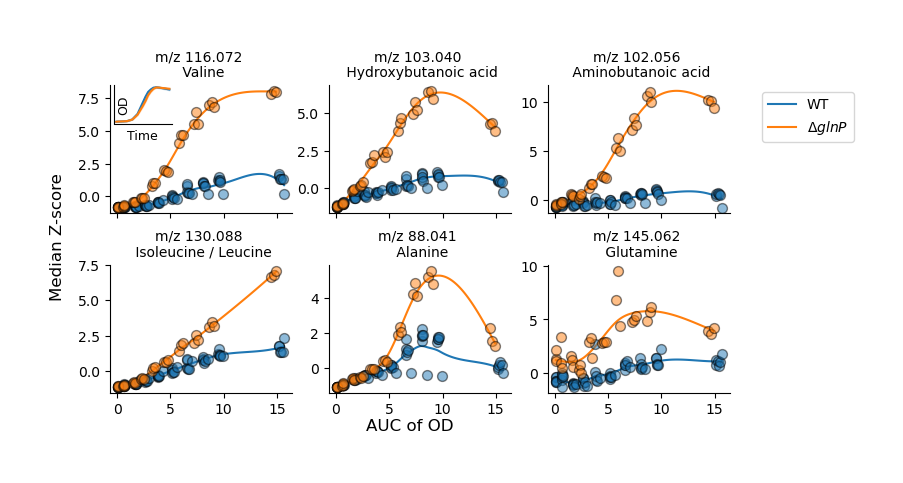

In [962]:
fig, axes = plt.subplots(2,3 , figsize=(8, 4), constrained_layout=False, sharex=True)
axes = axes.flatten()
data_to_plot = [
    ['glnP','Valine', 3], 
    ['glnP','Hydroxybutanoic acid', 3],
    ['glnP','Aminobutanoic acid (ABA)', 3],
    # ['glnP','Deoxyribose', 3],
    ['glnP','(Iso)Leucine', 3],
    ['glnP','Alanine', 3],
    # ['glnP','Cyclic GMP', 3],
    ['glnP','Glutamine', 3],
]

rename_dict = {
    'Valine': 'Valine',
    'Hydroxybutanoic acid': 'Hydroxybutanoic acid',
    'Aminobutanoic acid (ABA)': 'Aminobutanoic acid',
    '(Iso)Leucine': 'Isoleucine / Leucine',
    'Alanine': 'Alanine',
    'Glutamine': 'Glutamine'
}
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    plot_timecourse_difference(axes[i], df, [batch], strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    axes[i].set_title(f'm/z {ionMz[0]:.3f} \n {rename_dict[metabolite]}', size = 10)

    # --- OD curve inset ---
    if i == 0:
        inset_ax = axes[i].inset_axes([0.02, 0.7, 0.32, 0.3])  # [x0, y0, width, height]
        od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin([batch])].copy()
        l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain',hue_order=strains, ax = inset_ax)
        sns.despine(ax = inset_ax)
        inset_ax.set_xticks([])
        inset_ax.set_yticks([])
        inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
        inset_ax.set_xlabel('Time', size = 9)
        # inset_ax.yaxis.set_label_position('right')
        # inset_ax.set_title('OD', fontsize=8)
        # inset_ax.legend(fontsize=6, loc='upper left', frameon=False)
        # inset_ax.get_legend_handles_labels()
        
        handles, labels = inset_ax.get_legend_handles_labels()
        labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
        legend = inset_ax.legend(handles, labels, fontsize=10, loc='upper left', frameon=True, ncol=1, bbox_to_anchor=[11,1])
        legend.set_title(None)  # Remove legend title
        

fig.supylabel('Median Z-score', x=0.05, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    fig.supxlabel('Time [h]', size = 12)
else:
    fig.supxlabel('AUC of OD', size = 12)
sns.despine()
plt.subplots_adjust(hspace=0.4, right = 0.9)
plt.savefig(figure_folder / f'figure_5_ED_glnP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_ED_glnP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

# Negative effects

In [963]:
mz_to_name = {}
for key, value_list in name_to_ionMz.items():
    for mz in value_list:
        mz_to_name[mz] = key

In [964]:
dis_mz['Name'] = dis_mz.ionMz.map(mz_to_name)

In [965]:
dis_mz.sort_values(by='Rel. distance').head(20)

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names,Name
460,punC,344.0400,18.419066,-18.103784,0.397405,-0.390603,0.012852,0.030299,0.021576,punC,WT,0.0,0.0,cGMP,C00942;C06194,"Cyclic GMP / Guanosine 2',3'-cyclic phosphate",cGMP
2987,ygaZ,116.0718,13.707820,-13.683664,0.346247,-0.345637,0.021188,0.029330,0.025259,ygaZ,WT,0.0,0.0,Valine,C00183;C00719,Betaine / Valine,Valine
8439,glnP,147.0664,13.065258,-13.065258,1.395974,-1.395974,0.059313,0.154379,0.106846,glnP,WT,0.0,0.0,"(R) 2,3-Dihydroxy-3-methylvalerate",C00522;C06007,"(R) 2,3-Dihydroxy-3-methylvalerate / (R)-Pantoate",(R)-Pantoate
450,punC,322.0444,13.106362,-13.049091,0.506991,-0.504775,0.019417,0.057949,0.038683,punC,WT,0.0,0.0,CMP,C00055;C05822,3'-CMP / Cytidine monophosphate,CMP
8424,glnP,133.0508,12.418101,-12.418101,1.316825,-1.316825,0.048885,0.163196,0.106041,glnP,WT,0.0,0.0,Deoxyribose,C01801;C04039;C04272;C06257,"(R)-2,3-Dihydroxy-isovalerate / 1-Deoxy-xylulo...",Deoxyribose
465,punC,362.0506,12.389385,-12.183928,0.523613,-0.514929,0.023410,0.061116,0.042263,punC,WT,0.0,0.0,GMP,C00144;C06193;C18239;C19968,8-oxo-dGMP / Cyclic pyranopterin monophosphate...,GMP
3067,ygaZ,174.0409,11.365912,-11.313851,0.669483,-0.666417,0.044974,0.072832,0.058903,ygaZ,WT,0.0,0.0,Acetyl-Asp,C01042,N-Acetyl-aspartic acid,Acetyl-Asp
440,punC,304.0351,11.582395,-10.579716,0.437867,-0.399961,0.027195,0.048414,0.037805,punC,WT,0.0,0.0,"3',5'-Cyclic CMP",C02354,"2',3'-Cyclic CMP","3',5'-Cyclic CMP"
5134,adeP,344.0400,10.592711,-10.459288,0.488501,-0.482348,0.014946,0.077288,0.046117,adeP,WT,0.0,0.0,cGMP,C00942;C06194,"Cyclic GMP / Guanosine 2',3'-cyclic phosphate",cGMP
1958,ompF,547.0754,10.343581,-10.343581,0.829222,-0.829222,0.055069,0.105266,0.080168,ompF,WT,0.0,0.0,dTDP-6-deoxy-beta-L-talose,C03319,Deoxythymidine diphosphate-rhamnose,dTDP-6-deoxy-beta-L-talose


In [966]:
dis_mz.loc[dis_mz.Strain=='rhtC'].sort_values(by='Rel. distance').head(10)

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names,Name
11523,rhtC,328.0452,8.997312,-8.833995,0.627295,-0.615908,0.016534,0.122906,0.069720,rhtC,WT,0.0,0.0,"3',5'-Cyclic AMP",C00575;C02353,"Adenosine 2',3'-cyclic phosphate / Cyclic AMP","3',5'-Cyclic AMP"
11391,rhtC,147.0664,8.386863,-8.386863,1.457986,-1.457986,0.087696,0.259988,0.173842,rhtC,WT,0.0,0.0,"(R) 2,3-Dihydroxy-3-methylvalerate",C00522;C06007,"(R) 2,3-Dihydroxy-3-methylvalerate / (R)-Pantoate",(R)-Pantoate
11510,rhtC,304.0351,8.253922,-8.139234,0.736832,-0.726593,0.033784,0.144757,0.089270,rhtC,WT,0.0,0.0,"3',5'-Cyclic CMP",C02354,"2',3'-Cyclic CMP","3',5'-Cyclic CMP"
11530,rhtC,344.0400,8.034020,-7.997754,0.620191,-0.617391,0.019754,0.134637,0.077196,rhtC,WT,0.0,0.0,cGMP,C00942;C06194,"Cyclic GMP / Guanosine 2',3'-cyclic phosphate",cGMP
11376,rhtC,133.0508,5.836610,-5.836610,1.239021,-1.239021,0.085333,0.339235,0.212284,rhtC,WT,0.0,0.0,Deoxyribose,C01801;C04039;C04272;C06257,"(R)-2,3-Dihydroxy-isovalerate / 1-Deoxy-xylulo...",Deoxyribose
11511,rhtC,305.0193,4.163483,-3.644433,0.786872,-0.688774,0.206520,0.171467,0.188994,rhtC,WT,0.0,0.0,"2',3'-Cyclic UMP",C02355,"2',3'-Cyclic UMP","2',3'-Cyclic UMP"
11490,rhtC,253.0119,3.529141,-3.529141,0.784590,-0.784590,0.177646,0.266990,0.222318,rhtC,WT,0.0,0.0,Shikimate 3-phosphate,C03175,Shikimate 3-phosphate,Shikimate 3-phosphate
11323,rhtC,75.0089,3.484378,-3.336230,1.267214,-1.213335,0.264540,0.462829,0.363684,rhtC,WT,0.0,0.0,Glycolate,C00160,Glycolate,Glycolate
11502,rhtC,274.0932,3.250697,-3.250697,0.872443,-0.872443,0.203160,0.333613,0.268386,rhtC,WT,0.0,0.0,"1,6-Anhydro-N-acetyl-beta-muramate",C19769,"1,6-Anhydro-N-acetyl-beta-muramate","1,6-Anhydro-N-acetyl-beta-muramate"
11352,rhtC,117.0194,3.240240,-3.240240,0.697050,-0.697050,0.040651,0.389595,0.215123,rhtC,WT,0.0,0.0,Succinate,C00042,Succinic acid,Succinate


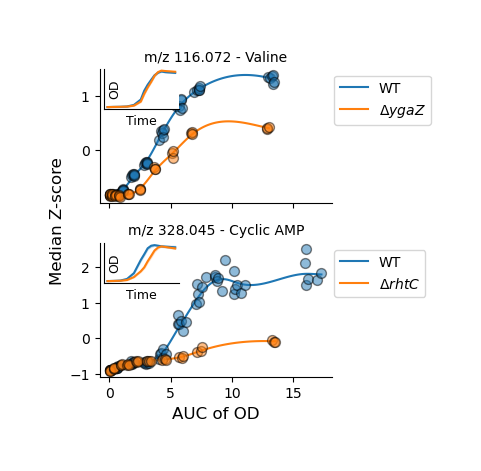

In [967]:
fig, axes = plt.subplots(2, 1, figsize=(3, 4), constrained_layout=False, sharex=True)
axes = axes.flatten()
data_to_plot = [
    ['ygaZ','Valine', 1], 
    ['rhtC',"Cyclic AMP", 4]
]
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]
    plot_timecourse_difference(axes[i], df, [batch], strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    axes[i].set_title(f'm/z {ionMz[0]:.3f} - {metabolite}', size = 10)

    # --- OD curve inset ---
    inset_ax = axes[i].inset_axes([0.02, 0.7, 0.32, 0.3])  # [x0, y0, width, height]

    od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin([batch])]
    l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain', hue_order=strains, ax = inset_ax)
    sns.despine(ax = inset_ax)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
    inset_ax.set_xlabel('Time', size = 9)
    # inset_ax.yaxis.set_label_position('right')
    # inset_ax.set_title('OD', fontsize=8)
    # inset_ax.legend(fontsize=6, loc='upper left', frameon=False)
    # inset_ax.get_legend_handles_labels()
    
    handles, labels = inset_ax.get_legend_handles_labels()
    labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
    legend = inset_ax.legend(handles, labels, fontsize=10, loc='upper left', frameon=True, ncol=1, bbox_to_anchor=[3,1])
    legend.set_title(None)  # Remove legend title
    

fig.supylabel('Median Z-score', x=-0.04, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    axes[-1].set_xlabel('Time [h]', size = 12)
else:
    axes[-1].set_xlabel('AUC of OD', size = 12)
sns.despine()
plt.subplots_adjust(hspace=0.3)
plt.savefig(figure_folder / f'figure_5_ygaZ_rhtC_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_ygaZ_rhtC_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

In [968]:
dis_mz.loc[dis_mz.Strain.isin(['punC', 'adeP'])].sort_values(by='Rel. distance').head(10)
# df.loc[df.Strain.isin(['punC', 'adeP']), 'Batch'].unique()

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names,Name
460,punC,344.0400,18.419066,-18.103784,0.397405,-0.390603,0.012852,0.030299,0.021576,punC,WT,0.0,0.0,cGMP,C00942;C06194,"Cyclic GMP / Guanosine 2',3'-cyclic phosphate",cGMP
450,punC,322.0444,13.106362,-13.049091,0.506991,-0.504775,0.019417,0.057949,0.038683,punC,WT,0.0,0.0,CMP,C00055;C05822,3'-CMP / Cytidine monophosphate,CMP
465,punC,362.0506,12.389385,-12.183928,0.523613,-0.514929,0.023410,0.061116,0.042263,punC,WT,0.0,0.0,GMP,C00144;C06193;C18239;C19968,8-oxo-dGMP / Cyclic pyranopterin monophosphate...,GMP
440,punC,304.0351,11.582395,-10.579716,0.437867,-0.399961,0.027195,0.048414,0.037805,punC,WT,0.0,0.0,"3',5'-Cyclic CMP",C02354,"2',3'-Cyclic CMP","3',5'-Cyclic CMP"
5134,adeP,344.0400,10.592711,-10.459288,0.488501,-0.482348,0.014946,0.077288,0.046117,adeP,WT,0.0,0.0,cGMP,C00942;C06194,"Cyclic GMP / Guanosine 2',3'-cyclic phosphate",cGMP
5124,adeP,322.0444,8.956061,-8.804761,0.670013,-0.658694,0.018640,0.130982,0.074811,adeP,WT,0.0,0.0,CMP,C00055;C05822,3'-CMP / Cytidine monophosphate,CMP
5127,adeP,328.0452,9.450689,-8.786683,0.492093,-0.457519,0.021130,0.083009,0.052070,adeP,WT,0.0,0.0,"3',5'-Cyclic AMP",C00575;C02353,"Adenosine 2',3'-cyclic phosphate / Cyclic AMP","3',5'-Cyclic AMP"
451,punC,323.0285,9.004945,-8.664866,0.563643,-0.542357,0.058406,0.066779,0.062593,punC,WT,0.0,0.0,UMP,C00105;C01168;C01368,3'-UMP / Pseudouridine 5'-phosphate / Uridine ...,UMP
5114,adeP,304.0351,8.237171,-8.190666,0.553481,-0.550356,0.020059,0.114327,0.067193,adeP,WT,0.0,0.0,"3',5'-Cyclic CMP",C02354,"2',3'-Cyclic CMP","3',5'-Cyclic CMP"
5139,adeP,362.0506,7.574870,-7.474973,0.607112,-0.599106,0.035224,0.125072,0.080148,adeP,WT,0.0,0.0,GMP,C00144;C06193;C18239;C19968,8-oxo-dGMP / Cyclic pyranopterin monophosphate...,GMP


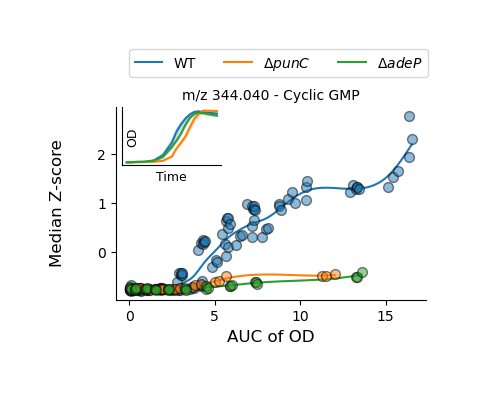

In [969]:
fig, ax = plt.subplots(1, 1, figsize=(4, 2.5), constrained_layout=False, sharex=True)
# axes = axes.flatten()
data_to_plot = [
    ['punC;adeP','Cyclic GMP', [1,2]], 
    # ['punC;adeP','Cytidine monophosphate', [1,2]], 
]
xval = 'AUC OD'
for i, (strain_str, metabolite, batch) in enumerate(data_to_plot):
    strains = ['WT'] + strain_str.split(';')
    ionMz = name_to_ionMz[metabolite]

    plot_timecourse_difference(ax, df, batch, strains, ionMz, xval=xval, yval='Median Z-score', ystd='Z-score std')
    ax.set_title(f'm/z {ionMz[0]:.3f} - {metabolite}', size = 10)

    # --- OD curve inset ---
    inset_ax = ax.inset_axes([0.02, 0.7, 0.32, 0.3])  # [x0, y0, width, height]
    od_data = od_df.loc[od_df.Strain.isin(strains)&od_df.Batch.isin(batch)]
    l = sns.lineplot(data = od_data, x = 'Hours', y = 'OD', hue = 'Strain', hue_order=strains, ax = inset_ax)
    sns.despine(ax = inset_ax)
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.set_ylabel('OD', labelpad = -12, size = 9)
    inset_ax.set_xlabel('Time', size = 9)
    # inset_ax.yaxis.set_label_position('right')
    # inset_ax.set_title('OD', fontsize=8)
    # inset_ax.legend(fontsize=6, loc='upper left', frameon=False)
    # inset_ax.get_legend_handles_labels()
    
    handles, labels = inset_ax.get_legend_handles_labels()
    labels = [f'Δ${lbl}$' if lbl != 'WT' else 'WT' for lbl in labels]
    legend = inset_ax.legend(handles, labels, fontsize=10, loc='lower left', frameon=True, ncol=3, bbox_to_anchor=[0,1.4])
    legend.set_title(None)  # Remove legend title
    

fig.supylabel('Median Z-score', x=-0.04, y=0.5, rotation=90, size = 12)
if xval == 'Hours':
    ax.set_xlabel('Time [h]', size = 12)
else:
    ax.set_xlabel('AUC of OD', size = 12)
sns.despine()
plt.subplots_adjust(hspace=0.3)
plt.savefig(figure_folder / f'figure_5_punC_adeP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.png', dpi=300, bbox_inches='tight')
plt.savefig(figure_folder / f'figure_5_punC_adeP_transporterKO_timecourses_{normalization}_norm_lam_{lam}_{xval}.pdf', dpi=300, bbox_inches='tight')

# Bar charts

In [970]:
all_strains = dis_mz['Strain'].unique()
N_changed_mets = sel_df.groupby('Strain')['Metabolite'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
N_changed_mets_neg = sel_df.loc[sel_df['Rel. distance'] < 0].groupby('Strain')['Metabolite'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
N_changed_mets_pos = sel_df.loc[sel_df['Rel. distance'] > 0].groupby('Strain')['Metabolite'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
met_changes = pd.merge(N_changed_mets_neg, N_changed_mets_pos, left_index=True, right_index=True, how='outer')
met_changes.columns = ['Decrease', 'Increase']
met_changes = met_changes.reset_index()
met_changes.dropna(inplace=True)
met_changes['Total'] = met_changes['Decrease'] + met_changes['Increase']
met_changes.sort_values(by=['Total', 'Strain'], ascending=False, inplace=True)



## Get transporter annotation

In [971]:
transporter_meta_fn = data_folder / 'B_selected_transporters_with_expression_levels.csv'
df_tmeta = pd.read_csv(transporter_meta_fn)

In [972]:
for i, row in df_tmeta.iterrows():
    if row['Type'] in ['Porin/channel']:
        df_tmeta.at[i, 'Type'] = 'Porin / channel'



/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/1821182968.py:9: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



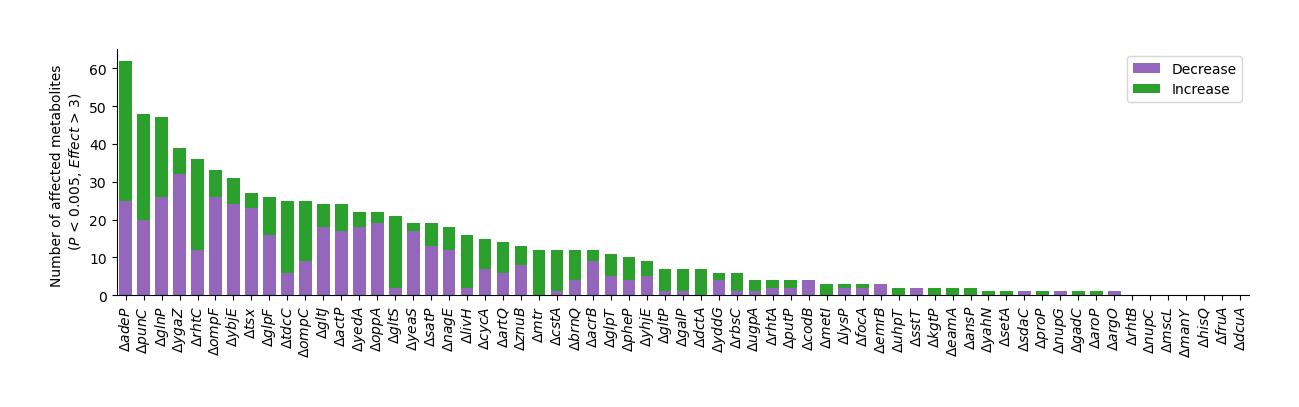

In [973]:
fig, ax = plt.subplots(figsize = (12,3))
bar_width = 0.7  # Adjust this value for wider/narrower bars

ax.bar(met_changes['Strain'], height = met_changes['Decrease'], width=bar_width, label='Decrease', color = 'C4')
ax.bar(met_changes['Strain'], height =  met_changes['Increase'], bottom=met_changes['Decrease'], width=bar_width, label='Increase', color = 'C2')
plt.xlim(-0.5, len(met_changes['Strain'])-0.5)
ax.legend()
plt.tight_layout()
ax.set_xticklabels([f'Δ${lbl}$' for lbl in met_changes['Strain']], rotation=90)
plt.ylabel('Number of affected metabolites \n ($P$ < 0.005, $Effect$ > 3)')
# ax.set_ylabel('Number of affected metabolites \n (Effect > %s and p-value < %s)'%(rel_dis_limit, p_val_limit))
sns.despine()
plt.show()


In [974]:
met_changes.tail(10)

,Strain,Decrease,Increase,Total
17,gadC,0,1,1
5,aroP,0,1,1
4,argO,1,0,1
45,rhtB,0,0,0
34,nupC,0,0,0
31,mscL,0,0,0
29,manY,0,0,0
25,hisQ,0,0,0
16,fruA,0,0,0
12,dcuA,0,0,0


In [975]:
in_out_color = {'Import':'w',
               'Export':'k',
               'Both':'gray'}

In [976]:

# Merge transporter type info into met_changes
met_changest = met_changes.merge(df_tmeta, left_on='Strain', right_on = 'Gene Name', how='left')
unique_types = sorted(met_changest['Type'].unique())
tab10 = plt.get_cmap('tab10')
type_to_color = {t: tab10(i) for i, t in enumerate(unique_types)}

In [977]:
dis_df.shape

(16621, 13)

In [978]:
sel_df.shape

(783, 16)

In [979]:
print(met_changest[['Decrease', 'Increase', 'Total']].sum())
met_changest[['Decrease', 'Increase', 'Total']].sum()/dis_df.shape[0]

Decrease    414
Increase    369
Total       783
dtype: int64


Decrease    0.024908
Increase    0.022201
Total       0.047109
dtype: float64

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/4136669775.py:9: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



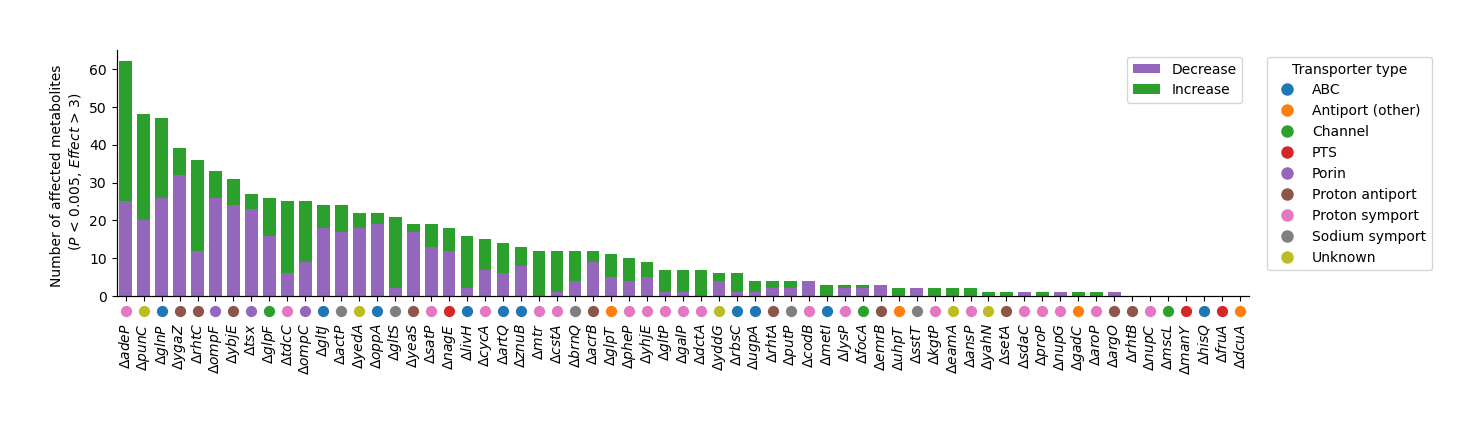

In [980]:


# Plot bars as before
fig, ax = plt.subplots(figsize=(12,3))
bar_width = 0.7
ax.bar(met_changest['Strain'], met_changest['Decrease'], width=bar_width, label='Decrease', color='C4')
ax.bar(met_changest['Strain'], met_changest['Increase'], bottom=met_changest['Decrease'], width=bar_width, label='Increase', color='C2')
plt.xlim(-0.5, len(met_changest['Strain'])-0.5)
ax.legend()
plt.tight_layout()
ax.set_xticklabels([f'Δ${lbl}$' for lbl in met_changest['Strain']], rotation=90, y = -0.07)
plt.ylabel('Number of affected metabolites \n ($P$ < 0.005, $Effect$ > 3)')

# Create a twin x-axis for the dots
ax_dots = ax.twiny()
ax_dots.set_xlim(ax.get_xlim())
ax_dots.set_xticks([])  # Hide ticks

# Place dots just above the tick labels
y_marker = -0.06  # Fraction of axes height above the bottom
for i, (strain, ttype) in enumerate(zip(met_changest['Strain'], met_changest['Type'])):
    ax_dots.scatter(i, y_marker, marker='o', color=type_to_color.get(ttype, 'gray'), s=50, zorder=10, clip_on=False, 
    transform=ax_dots.get_xaxis_transform())
sns.despine()



# Create round legend handles for transporter type
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=type_to_color[t], markersize=10, label=t)
    for t in type_to_color
]


# Add legend to the main axis (ax)
ax_dots.legend(handles=legend_handles, title="Transporter type", bbox_to_anchor=(1.01, 1), loc='upper left')

# # Create a twin x-axis for the dots
# ax_dots2 = ax.twiny()
# ax_dots2.set_xlim(ax.get_xlim())
# ax_dots2.set_xticks([])  # Hide ticks

# # Place dots just above the tick labels
# y_marker = -0.12  # Fraction of axes height above the bottom
# for i, (strain, in_out) in enumerate(zip(met_changest['Strain'], met_changest['Expected direction'])):
#     ax_dots2.scatter(i, y_marker, marker='o', color=in_out_color.get(in_out, 'red'),edgecolor = 'k', s=50, zorder=10, clip_on=False, 
#     transform=ax_dots2.get_xaxis_transform())
# sns.despine()
# # Create legend handles for each transporter type
# legend_handles2 = [
#     Line2D([0], [0], marker='o', color='w',markeredgecolor='k', markerfacecolor=in_out_color[t], markersize=10, label=t)
#     for t in in_out_color
# ]

# Add legend to the main axis (ax)
# ax_dots2.legend(handles=legend_handles2, title="Expected direction", bbox_to_anchor=(0.7, 1), loc='upper left')

plt.savefig(figure_folder / f'figure_5_number_of_changed_metabolites_per_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [981]:
len(met_changes)

63

In [982]:
((met_changes['Decrease'] > 0)&(met_changes['Increase'] > 0)).sum()

np.int64(38)

In [983]:
met_changest['Fraction'] = met_changest['Increase'] / met_changest['Total']

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/3538649432.py:5: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



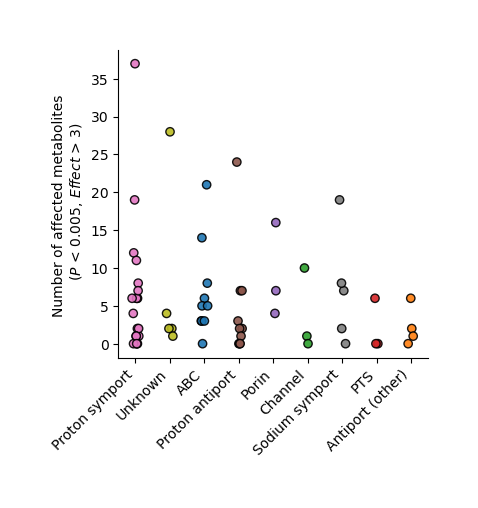

In [984]:
fog, ax = plt.subplots(figsize=(4,4))
sns.stripplot(data = met_changest, x='Type', y='Increase', jitter=True, hue = 'Type', palette=type_to_color, dodge=False, size = 6, edgecolor='k', alpha=0.9, linewidth = 1,
                ax = ax)
plt.ylabel(f'Number of affected metabolites \n ($P$ < 0.005, $Effect$ > {min_effect})')
ax.set_xticklabels(plt.gca().get_xticklabels(), rotation=45, ha='right')
plt.xlabel('')
sns.despine()

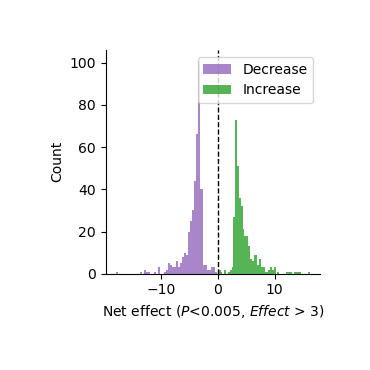

In [985]:
plt.figure(figsize=(3, 3))
data = sel_df['Rel. distance']

# plt.hist(dis_mz['Rel. distance'], bins=100, alpha=0.3, color='grey', label='All')
plt.hist(data[data < 0], bins=50, alpha=0.8, color='C4', label='Decrease')
plt.hist(data[data > 0], bins=50, alpha=0.8, color='C2', label='Increase')

plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Net effect ($P$<%s, $Effect$ > %s)'%(max_pval, min_effect))
plt.ylabel('Count')
plt.legend()
# plt.yscale('log')
# plt.title('Overlay of Negative and Positive Rel. distance')
# plt.title('Distribution of net effects ($P$<%s, $Effect$ > %s)'%(max_pval, min_effect))
plt.tight_layout()
sns.despine()
plt.savefig(figure_folder / f'figure_5_distribution_of_net_effects_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [1018]:
l[1]

array([-18.10378442, -17.75971556, -17.4156467 , -17.07157784,
       -16.72750898, -16.38344012, -16.03937126, -15.6953024 ,
       -15.35123354, -15.00716468, -14.66309582, -14.31902697,
       -13.97495811, -13.63088925, -13.28682039, -12.94275153,
       -12.59868267, -12.25461381, -11.91054495, -11.56647609,
       -11.22240723, -10.87833837, -10.53426951, -10.19020066,
        -9.8461318 ,  -9.50206294,  -9.15799408,  -8.81392522,
        -8.46985636,  -8.1257875 ,  -7.78171864,  -7.43764978,
        -7.09358092,  -6.74951206,  -6.4054432 ,  -6.06137435,
        -5.71730549,  -5.37323663,  -5.02916777,  -4.68509891,
        -4.34103005,  -3.99696119,  -3.65289233,  -3.30882347,
        -2.96475461,  -2.62068575,  -2.27661689,  -1.93254804,
        -1.58847918,  -1.24441032,  -0.90034146,  -0.5562726 ,
        -0.21220374,   0.13186512,   0.47593398,   0.82000284,
         1.1640717 ,   1.50814056,   1.85220942,   2.19627827,
         2.54034713,   2.88441599,   3.22848485,   3.57

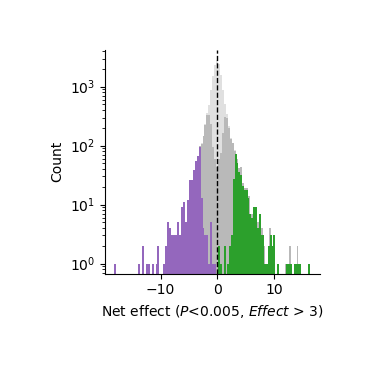

In [1038]:
plt.figure(figsize=(3, 3))
data = sel_df['Rel. distance']

l = plt.hist(dis_mz['Rel. distance'], bins=100, alpha=0.7, color='lightgray', label='All', lw = 0)#histtype='step', zorder = 10
plt.hist(dis_mz.loc[dis_mz['p-value rel']<max_pval, 'Rel. distance'], bins=l[1], alpha=.7, color='darkgrey', label='Significant (p<%s)'%max_pval, lw = 0)

# plt.hist(dis_mz['Rel. distance'], bins=100, alpha=0.3, color='grey', label='All')
plt.hist(data[data < 0], bins=l[1], alpha=1, color='C4', label='Decrease')
plt.hist(data[data > 0], bins=50, alpha=1, color='C2', label='Increase')

plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Net effect ($P$<%s, $Effect$ > %s)'%(max_pval, min_effect))
plt.ylabel('Count')
# plt.legend()
plt.yscale('log')
# plt.title('Overlay of Negative and Positive Rel. distance')
# plt.title('Distribution of net effects ($P$<%s, $Effect$ > %s)'%(max_pval, min_effect))
plt.tight_layout()
sns.despine()
plt.savefig(figure_folder / f'figure_5_distribution_of_net_effects_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 

## Metabolite centric

In [986]:
met_class_fn = data_folder / 'Z_div/G_metabolite_info.tsv'
met_info_df = pd.read_csv(met_class_fn, sep='\t')

In [987]:
met_info_df

,KEGG,Metabolite name,PubChem,ChEBI,SMILES,kingdom,superclass,class,subclass,geometric_descriptor,Classification
0,C00001,Water,962.0,15377,O,Organic compounds,Organic oxygen compounds,Organic oxides,Organic oxides,Acyclic compounds,Organic oxygen compounds
1,C00002,Adenosine triphosphate,5957.0,15422,NC1=NC=NC2=C1N=CN2[C@@H]1O[C@H](COP(O)(=O)OP(O...,Organic compounds,"Nucleosides, nucleotides, and analogues",Purine nucleotides,Purine ribonucleotides,Aromatic heteropolycyclic compounds,Nucleotides / nucleosides
2,C00003,NAD,5892.0,44215,NC(=O)C1=C[N+](=CC=C1)[C@@H]1O[C@H](COP([O-])(...,Organic compounds,"Nucleosides, nucleotides, and analogues",Pyridine nucleotides,Pyridine nucleotides,Aromatic heteropolycyclic compounds,Nucleotides / nucleosides
3,C00004,NADH,439153.0,16908,NC(=O)C1=CN(C=CC1)[C@@H]1O[C@H](COP(O)(=O)OP(O...,Organic compounds,"Nucleosides, nucleotides, and analogues",Pyridine nucleotides,Nicotinamide nucleotides,Aromatic heteropolycyclic compounds,Nucleotides / nucleosides
4,C00005,NADPH,5884.0,16474,NC(=O)C1=CN(C=CC1)[C@@H]1O[C@H](COP(O)(=O)OP(O...,Organic compounds,"Nucleosides, nucleotides, and analogues",Purine nucleotides,Purine ribonucleotides,Aromatic heteropolycyclic compounds,Nucleotides / nucleosides
...,...,...,...,...,...,...,...,...,...,...,...
1672,C22458,8-Amino-7-(carboxyamino)nonanoate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown
1673,C22501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown
1674,C22502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown
1675,C22507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown


In [988]:
all_metabolites = dis_mz['ionMz'].unique()
# N_changed_strains = sel_df.groupby('ionMz')['Strain'].count().reindex(all_metabolites, fill_value=0).sort_values(ascending=False)
N_changed_strains_neg = sel_df.loc[sel_df['Rel. distance'] < 0].groupby('ionMz')['Strain'].count().reindex(all_metabolites, fill_value=0).sort_values(ascending=False)
N_changed_strains_pos = sel_df.loc[sel_df['Rel. distance'] > 0].groupby('ionMz')['Strain'].count().reindex(all_metabolites, fill_value=0).sort_values(ascending=False)
strain_changes = pd.merge(N_changed_strains_neg, N_changed_strains_pos, left_index=True, right_index=True, how='outer')
strain_changes.columns = ['Decrease', 'Increase']
strain_changes = strain_changes.reset_index()
strain_changes.dropna(inplace=True)
strain_changes['Total'] = strain_changes['Decrease'] + strain_changes['Increase']
strain_changes.sort_values(by=['Total'], ascending=[True], inplace=True)
strain_changes = strain_changes[strain_changes['Total'] > 0]

In [989]:
# strain_changes.tail(100)

In [990]:
strain_changes = strain_changes.merge(df_ionMz, on = 'ionMz', how='left')

In [991]:
# strain_changes.rename(columns={'Metabolite': 'Name'}, inplace=True)

In [992]:
met_info_df.drop_duplicates('KEGG', inplace=True)

In [993]:
kegg_to_class = {row['KEGG']: row['Classification'] for _, row in met_info_df.iterrows()}

In [994]:
all_classes = []

move_to_other = ['Benzenoids', 'Other organic acids', 'Phenylpropanoids and polyketides', 'Organic nitrogen compounds']
for i, row in strain_changes.iterrows():
    kegg_ids = row['KEGG'].split(';')
    classes = set([kegg_to_class.get(kegg, 'Unknown') for kegg in kegg_ids])
    classes = {c if c not in move_to_other else 'Other' for c in classes}
    if len(classes) > 1:
        classes.discard('Unknown')
    all_classes += list(classes)
    if len(classes) >1:
        strain_changes.at[i, 'Classification'] = 'Mixed'
        strain_changes.at[i, 'Classes'] = ';'.join(classes)
    else:
        strain_changes.at[i, 'Classification'] = classes.pop()
        strain_changes.at[i, 'Classes'] = strain_changes.at[i, 'Classification']
        

    

In [995]:
pd.DataFrame(all_classes).value_counts()

0                           
Amino acids                     48
Organoheterocyclic compounds    22
Organic oxygen compounds        17
Other                           17
Keto / hydroxy acids            16
Nucleotides / nucleosides       14
Unknown                         14
Lipid-like molecules            12
Carboxylic acids                11
Name: count, dtype: int64

In [996]:
strain_changes

,ionMz,Decrease,Increase,Total,Metabolite,KEGG,All metabolite names,Classification,Classes
0,388.9444,0,1,1,Phosphoribosyl pyrophosphate,C00119,Phosphoribosyl pyrophosphate,Organic oxygen compounds,Organic oxygen compounds
1,273.0016,0,1,1,3-Dehydro-gulonate 6-phosphate,C05385;C14899,3-Dehydro-gulonate 6-phosphate / Glucuronate 1...,Organic oxygen compounds,Organic oxygen compounds
2,129.0560,0,1,1,4-Methyl-2-oxopentanoate,C00233;C00671;C03465,2-Keto-3-methyl-valerate / 3-Methyl-2-oxovaler...,Keto / hydroxy acids,Keto / hydroxy acids
3,267.0720,0,1,1,2(alpha-D-Mannosyl)-D-glycerate,C11544,2(alpha-Mannosyl)-glycerate,Unknown,Unknown
4,175.0611,0,1,1,3-Propylmalate,C02504;C04411,2-Isopropylmalic acid / 3-Carboxy-3-hydroxy-is...,Mixed,Lipid-like molecules;Keto / hydroxy acids
...,...,...,...,...,...,...,...,...,...
145,189.0880,14,6,20,Diaminopimelate,C00666;C00680,"Diaminopimelic acid / Meso-2,6-Diaminoheptaned...",Amino acids,Amino acids
146,322.0444,15,7,22,CMP,C00055;C05822,3'-CMP / Cytidine monophosphate,Nucleotides / nucleosides,Nucleotides / nucleosides
147,289.1043,14,8,22,"N-Succinyl-LL-2,6-diaminoheptanedioate",C04421,"N-Succinyl-L,2,6-diaminopimelate",Amino acids,Amino acids
148,288.0726,15,7,22,N-Succinyl-2-L-amino-6-oxoheptanedioate,C04462,N-Succinyl-2-amino-6-ketopimelate,Amino acids,Amino acids


In [997]:
class_to_color = {cls: plt.cm.tab20(i) for i, cls in enumerate(sorted(list(set(all_classes))))}

In [998]:
strain_changes.Classification.value_counts()

Classification
Amino acids                     46
Mixed                           21
Other                           15
Organoheterocyclic compounds    15
Unknown                         14
Keto / hydroxy acids             9
Lipid-like molecules             9
Nucleotides / nucleosides        8
Organic oxygen compounds         7
Carboxylic acids                 6
Name: count, dtype: int64

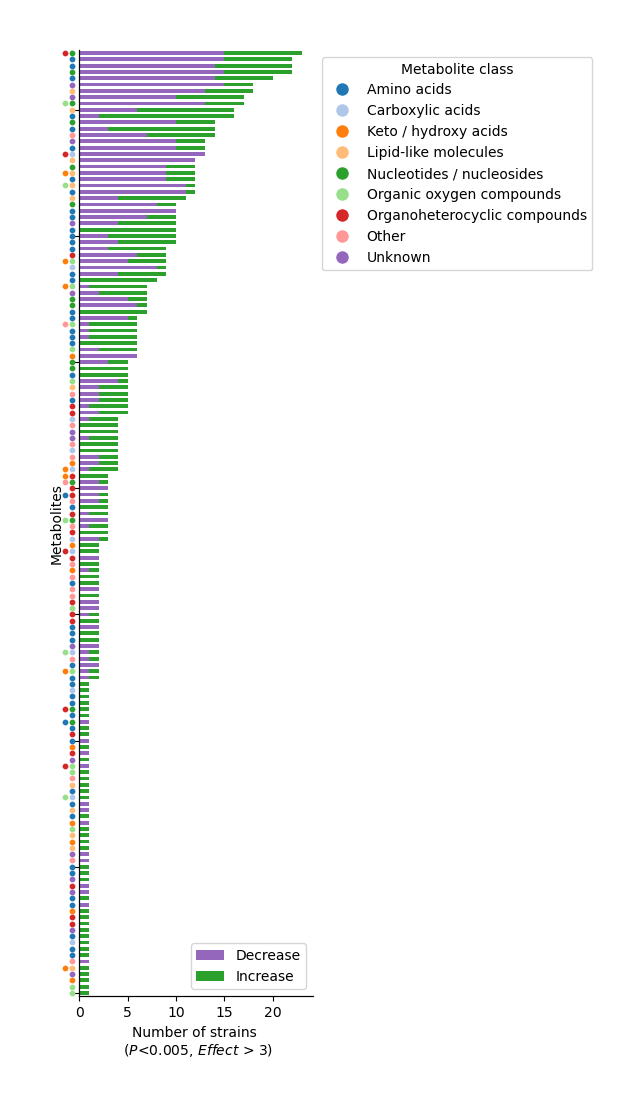

In [999]:
fig, ax = plt.subplots(figsize = (3,10))
bar_width = 0.6  # Adjust this value for wider/narrower bars

ax.barh(strain_changes.index, width = strain_changes['Total'], height=bar_width, label='Decrease', color = 'C4')
ax.barh(strain_changes.index, width =  strain_changes['Increase'], left=strain_changes['Decrease'], height=bar_width, label='Increase', color = 'C2')
plt.ylim(-0.5, len(strain_changes['Metabolite'])-0.5)
ax.legend()
plt.tight_layout()
# ax.set_xticklabels([lbl for lbl in strain_changes['Metabolite']], rotation=90, size = 6)
ax.set_yticklabels([])
plt.xlabel('Number of strains \n ($P$<%s, $Effect$ > %s)'%(max_pval, min_effect))
plt.ylabel('Metabolites')
# ax.set_ylabel('Number of affected metabolites \n (Effect > %s and p-value < %s)'%(rel_dis_limit, p_val_limit))
sns.despine()


# Create a twin x-axis for the dots
ax_dots = ax.twinx()
ax_dots.set_ylim(ax.get_ylim())
ax_dots.set_yticks([])  # Hide ticks

# Place dots just above the tick labels
x_marker = -0.03  # Fraction of axes height above the bottom
for i, row in strain_changes.iterrows():
    # ax_dots.plot([x_marker, -0.01], [i,i], color=class_to_color[row['Classification']], lw = 3, zorder=10, clip_on=False, 
    # transform=ax_dots.get_yaxis_transform())
    met_classes = row['Classes'].split(';')
    for j, met_class in enumerate(met_classes):
        ax_dots.scatter(x_marker - j*0.03, i, color=class_to_color[met_class], s= 10, zorder=10, clip_on=False, 
        transform=ax_dots.get_yaxis_transform())
    # ax_dots.scatter(x_marker, i, color=class_to_color[row['Classification']], s= 10, zorder=10, clip_on=False, 
    # transform=ax_dots.get_yaxis_transform())
sns.despine()

# for i, (strain, ttype) in enumerate(zip(met_changest['Strain'], met_changest['Type'])):
#     ax_dots.scatter(i, y_marker, marker='o', color=type_to_color.get(ttype, 'gray'), s=50, zorder=10, clip_on=False, 
#     transform=ax_dots.get_xaxis_transform())
# sns.despine()


# Create round legend handles for transporter type
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=class_to_color[t], markersize=10, label=t)
    for t in class_to_color
]
# end to the main axis (ax)
ax_dots.legend(handles=legend_handles, title="Metabolite class", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.savefig(figure_folder / f'figure_5_number_of_changed_strains_per_metabolite_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [1000]:
print(len(strain_changes))
print(((strain_changes['Decrease']>0)&(strain_changes['Increase']>0)).sum())

150
65


In [1001]:
class_to_color['Mixed'] = 'gray'

<Axes: xlabel='Total', ylabel='Classification'>

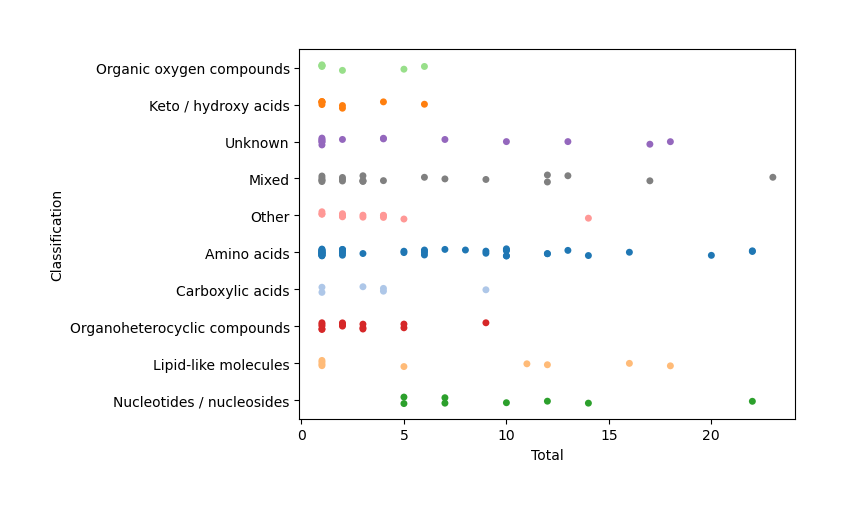

In [1002]:
sns.stripplot(data = strain_changes, y = 'Classification', x = 'Total', hue = 'Classification', palette=class_to_color, dodge=False)

# Chord diagram


In [1003]:
met_changes

,Strain,Decrease,Increase,Total
2,adeP,25,37,62
41,punC,20,28,48
19,glnP,26,21,47
60,ygaZ,32,7,39
46,rhtC,12,24,36
...,...,...,...,...
31,mscL,0,0,0
29,manY,0,0,0
25,hisQ,0,0,0
16,fruA,0,0,0


In [1004]:
met_changes

,Strain,Decrease,Increase,Total
2,adeP,25,37,62
41,punC,20,28,48
19,glnP,26,21,47
60,ygaZ,32,7,39
46,rhtC,12,24,36
...,...,...,...,...
31,mscL,0,0,0
29,manY,0,0,0
25,hisQ,0,0,0
16,fruA,0,0,0


In [1005]:
total = strain_changes.Total.sum()+met_changest.Total.sum()+len(met_changest)+len(strain_changes)

In [1006]:
# Define the colors: C2 for negative, white for zero, C4 for positive
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "custom_diverging", ["C4", "C2"]
)
# Define color stops: green for negative, wide white for zero, red for positive
# cmap = mpl.colors.LinearSegmentedColormap.from_list(
#     "custom_diverging",
#     [
#         (0.0, "C2"),   # green
#         (0.40, "white"),    # white starts earlier
#         (0.60, "white"),    # white ends later
#         (1.0, "C4"),   # red
#     ]
# )


# Normalize so that 0 is the center
vmin = -20#sel_df['Rel. distance'].min()
vmax = +20#sel_df['Rel. distance'].max()
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)


In [1007]:
r1 = 50
r2 = 75
r3 = 81


met_changest.sort_values(by='Total', inplace=True, ascending=True)
met_changest.reset_index(inplace=True, drop=True)
strain_changes.sort_values(by='Total', inplace=True, ascending=False)
strain_changes.reset_index(inplace=True, drop=True)

strain_to_total = met_changest.set_index('Strain')['Total'].to_dict()
strain_to_decrease = met_changest.set_index('Strain')['Decrease'].to_dict()
strain_to_type = met_changest.set_index('Strain')['Type'].to_dict()

met_to_total = strain_changes.set_index('ionMz')['Total'].to_dict()
met_to_decrease = strain_changes.set_index('ionMz')['Decrease'].to_dict()
met_to_class = strain_changes.set_index('ionMz')['Classes'].to_dict()

sectors = OrderedDict()
# for i, row in strain_changes.iterrows():
#     sectors[row['ionMz']] = (row['Total']+1)*360/total
# for i, row in met_changest.iterrows():
#     sectors[row['Strain']] = (row['Total']+1)*360/total


prev_x = 0
min_width = 4
for i, row in met_changest.iterrows():
    width = max(row['Total'],min_width)
    sectors[row['Strain']] = (prev_x, prev_x + width)
    prev_x += width

for i, row in strain_changes.iterrows():
    width = max(row['Total'],min_width)
    sectors[row['ionMz']] = (prev_x, prev_x+width)
    prev_x += width

# prev_x += 20



met_sectors = {row['ionMz']: (row['Total']+1)*360/total for i, row in strain_changes.iterrows()}
strain_sectors = {row['Strain']: (row['Total']+1)*360/total for i, row in met_changest.iterrows()}
# # strains = met_changest.Strain.unique().tolist()
# # sectors = OrderedDict()
sectors = {**strain_sectors, **met_sectors}
spaces = list(np.ones(len(sectors)))
spaces[len(strains)-1] = 10
spaces[-1] = 10
circos = Circos(sectors=sectors,
                space = spaces,
                start = -180,
                end = 180,
                # endspace = 30
                # sector2clockwise = {sector:False for sector in sectors.keys()}
            )

sector_name_to_index = {sector.name: i for i, sector in enumerate(circos.sectors)}
for sector in circos.sectors:
    # Plot sector axis & name text
    # sector.axis(fc="none", ls="dashdot", lw=2, ec="black", alpha=0.5)
    # sector.text(f"Sector: {sector.name}={sector.size}", size=15)
    # print(sector.name, sector.size)
    btrack = sector.add_track((r1, r2))
    btrack.axis(ec = 'k', lw=0)
    # btrack.grid(5)

    if sector.name in strains:
        btrack.bar(x = [sector._start], height = [strain_to_total[sector.name]], vmax = 30, width = sector.size, color='C2', align='edge')#edgecolor='k')
        btrack.bar(x = [sector._start], height = [strain_to_decrease[sector.name]], vmax = 30, width = sector.size, color='C4', align='edge')#, edgecolor='')
        sector.rect(r_lim=(r2, r3), fc=type_to_color[strain_to_type[sector.name]], ec=None, lw=0)

        if sector.name == 'adeP':
            yticks = [0, 5, 10, 15, 20, 25]
            btrack.yticks(yticks,labels = [str(x) for x in yticks], side = 'right')
    else:
        btrack.bar(x = [sector._start], height = [met_to_total[sector.name]], vmax = 15, width = sector.size, color='C2', align='edge')#edgecolor='k')
        btrack.bar(x = [sector._start], height = [met_to_decrease[sector.name]], vmax = 15, width = sector.size, color='C4', align='edge')#, edgecolor='')
        met_classes = met_to_class[sector.name].split(';')
        if len(met_classes) == 1:
            sector.rect(r_lim=(r2, r3), fc=class_to_color[met_classes[0]], ec=None, lw=0)
        else:
            sector.rect(r_lim=(r2, (r3+r2)/2), fc=class_to_color[met_classes[0]], ec=None, lw=0)
            sector.rect(r_lim=((r3+r2)/2, r3), fc=class_to_color[met_classes[1]], ec=None, lw=0)
        if sector.name == strain_changes.iloc[0]['ionMz']:
            yticks = [0, 3, 6, 9, 12]
            btrack.yticks(yticks,labels = [str(x) for x in yticks], side = 'left')
        # btrack.bar(x = [0], height = [
    # else:
        # print(sector.size)
first_strain_sector = circos.sectors[0]
last_strain_sector = circos.sectors[len(strains)-1]
first_met_sector = circos.sectors[len(strains)]
last_met_sector = circos.sectors[-1]


circos.rect(r_lim=(102, 107), fc="C0", ec="black",deg_lim=(first_strain_sector.deg_lim[0],last_strain_sector.deg_lim[1]))
circos.rect(r_lim=(102, 107), fc="C1", ec="black",deg_lim=(first_met_sector.deg_lim[0],last_met_sector.deg_lim[1]))

circos.rect(r_lim=(r1, r2), fc="w", ec="black", lw = 1, deg_lim=(first_strain_sector.deg_lim[0],last_strain_sector.deg_lim[1]))
circos.rect(r_lim=(r1, r2), fc="w", ec="black", lw = 1, deg_lim=(first_met_sector.deg_lim[0],last_met_sector.deg_lim[1]))

r_extra  = np.linspace(r1, r2, 5, endpoint=True)
for i in [1, 3]:
    circos.rect(r_lim=(r_extra[i-1], r_extra[i]), fc="w", ec="gray", lw = 1, deg_lim=(first_strain_sector.deg_lim[0],last_strain_sector.deg_lim[1]))
    circos.rect(r_lim=(r_extra[i-1], r_extra[i]), fc="w", ec="gray", lw = 1, deg_lim=(first_met_sector.deg_lim[0],last_met_sector.deg_lim[1]))


# Each link goes between onbe region in a sector to one region in another sector
metabolite_region_counter = defaultdict(int)
strain_region_counter = defaultdict(int)
ss = 1
ms = 1
for sector in circos.sectors:
    if sector.name in strains:
        dfi = sel_df.loc[sel_df.Strain==sector.name].sort_values(by='Rel. distance', ascending=False)
        #(strain_to_total[sector.name] + min_width)/(strain_to_total[sector.name])
        ss = sector.size/max(1, strain_to_total[sector.name])
        for j, (_, row) in enumerate(dfi.iterrows()):
            color = cmap(norm(row['Rel. distance']))
            si = strain_region_counter[sector.name]
            mname = row['ionMz']
            msector = circos.sectors[sector_name_to_index[mname]]
            mi = metabolite_region_counter[mname]
            ms = msector.size/max(1, met_to_total[mname])
            print(sector.name, si, si+ss, mname, mi, mi+ms, ms, met_to_total[mname], msector.size/met_to_total[mname])
            circos.link((sector.name, si, si+ss), (msector.name, mi, mi+ms), color=color, 
                        lw=1, alpha=1, ec = color, zorder = row['Rel. abs. distance'])
            strain_region_counter[sector.name] += ss 
            metabolite_region_counter[mname] += ms

# for sector in circos.sectors: 
        #     if sector.name in strains:
#         sector.text(sector.name, size=8, color='k', r=105, rotation='vertical', ha='center', va='center')
#         print(sector)
#         bar_track = sector.add_track((100, 125))
#         bar_track.axis()
#         bar_track.bar(x = 0, height = met_changest.loc[met_changest.Strain==sector.name, 'Total'].values[0], width=2, color='C2', align='edge')#edgecolor='k')
#         bar_track.bar(x = 0, height = met_changest.loc[met_changest.Strain==sector.name, 'Decrease'].values[0], width=2, color='C4', vmax = met_changest.Total.max(), align = 'edge')#, edgecolor='')

fig = circos.plotfig(figsize=(10,10))

KeyError: 'dcuA'

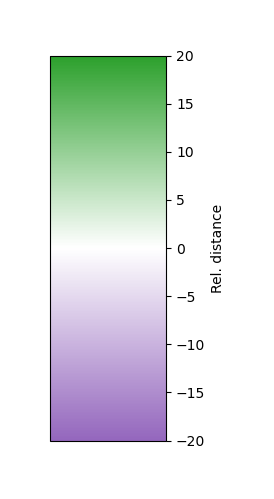

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Define the colors: C2 for negative, white for zero, C4 for positive
cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "custom_diverging", ["C4", "white", "C2"]
)

# Normalize so that 0 is the center
vmin = -20#sel_df['Rel. distance'].min()
vmax = +20#sel_df['Rel. distance'].max()
norm = mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Example: create a colorbar only
fig, ax = plt.subplots(figsize=(1.5, 5))
cb = mpl.colorbar.ColorbarBase(
    ax,
    cmap=cmap,
    norm=norm,
    orientation='vertical',
    label='Rel. distance'
)
plt.show()

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2951667894.py:30: UserWarning:

r_lim=(140, 150) is unexpected plot range (0 <= r <= 100).

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2951667894.py:40: UserWarning:

r_lim=(130, 140) is unexpected plot range (0 <= r <= 100).

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2951667894.py:62: UserWarning:

r_lim=(130, 135) is unexpected plot range (0 <= r <= 100).

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2951667894.py:63: UserWarning:

r_lim=(135, 140) is unexpected plot range (0 <= r <= 100).



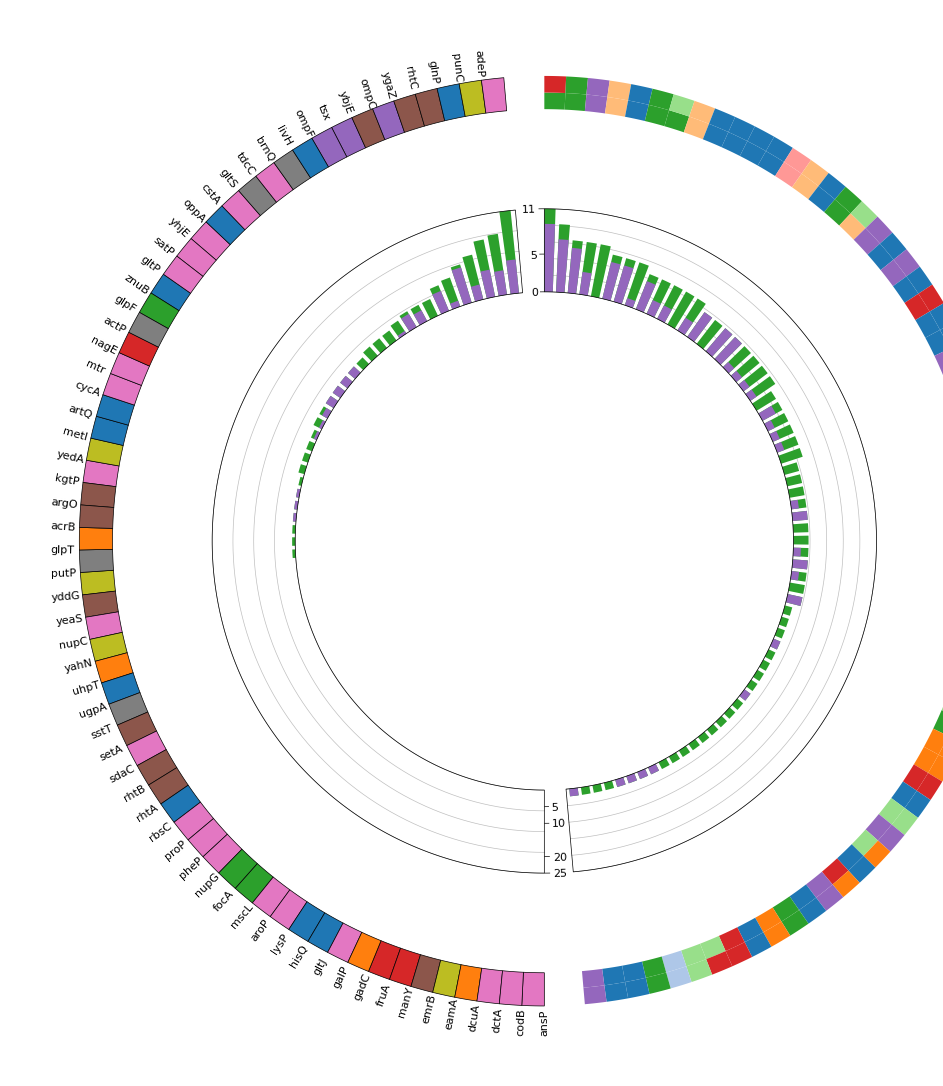

In [ ]:

met_sectors = {row['Metabolite']: row['Total'] for i, row in strain_changes.iterrows()}
strain_sectors = {row['Strain']: row['Total']+1 for i, row in met_changes.iterrows()}
# sectors = {**met_sectors, **strain_sectors}


# circos = Circos(sectors=sectors,
#                 space = 1,
#                 start = 0,
#                 end = 360,)
sectors = {'Transporters':180, 'Metabolites':180}
circos = Circos(sectors=sectors,
                space = 5,
                start = -180,
                end = 180,
            )


tsector = circos.sectors[0]
bar_track = tsector.add_track((75, 100))
bar_track.axis()
xt = [x*180/len(met_changest.index) for x in range(len(met_changest.index))]
bar_track.bar(x = xt, height = met_changest['Total'].values, width=2, color='C2', align='edge')#edgecolor='k')
bar_track.bar(x = xt, height = met_changest['Decrease'].values, width=2, color='C4',vmin = 0, vmax = met_changest.Total.max(), align = 'edge')#, edgecolor='')
bar_track.grid(5)
bar_track.yticks([5,10,20,25],labels = ['5','10','20','25'], side = 'left')
# label_track = tsector.add_track((145, 150))
# label_track.text(tsector.name, size=10, color='k', r=160, rotation='vertical', ha='center', va='center')
# label_track.axis(fc='white', ec='black')
# label_track.xticks_by_interval(interval=10, label_orientation="vertical")
name_track = tsector.add_track((140, 150))
for i, row in met_changest.iterrows():
    angle = -xt[i]
    perp_angle = angle + 90 
    x = xt[i]
    name_track.text(row['Strain'],xt[i], r=145, size=8, rotation=perp_angle, ha='center', va='center', adjust_rotation=False)
    # name_track.annotate(xt[i], row['Strain'])
# for i, row in met_changes.iterrows():
#     angle = (xt[i] + 1)/180 * np.pi
#     label_track.text(angle, row['Strain'], r=72, size=6, rotation='vertical', ha='center', va='center')
class_track = tsector.add_track((130, 140))
rect_size = 180 / len(met_changest.index)
for i, row in met_changest.iterrows():
    x1, x2 = i * rect_size, i * rect_size + rect_size
    class_track.rect(x1, x2, ec="black", lw=0.5, color=type_to_color[row['Type']])
    # class_track.text(str(i + 1), (x1 + x2) / 2, size=8, color="white")
# for i in range(int(rect_track.size / rect_size)):
#     x1, x2 = i * rect_size, i * rect_size + rect_size
#     rect_track.rect(x1, x2, ec="black", lw=0.5, color=ColorCycler())
#     rect_track.text(str(i + 1), (x1 + x2) / 2, size=8, color="white")
    # Generate random x, y plot data

msector = circos.sectors[1]
mbar_track = msector.add_track((75, 100))
mbar_track.axis()
xm = [x*180/len(strain_changes.index) for x in range(len(strain_changes.index))]
mbar_track.bar(x = xm, height = strain_changes['Total'].values, vmax = strain_changes.Total.max(), width=2, color='C2', align='edge')#edgecolor='k')
mbar_track.bar(x = xm, height = strain_changes['Decrease'].values, width=2, color='C4', vmax = strain_changes.Total.max(), align = 'edge')#, edgecolor='')
mbar_track.grid(6)
yticks = [0,5,11]
mbar_track.yticks(yticks,labels = [str(x) for x in yticks], side = 'left')

mclass_track1 = msector.add_track((130, 135))
mclass_track2 = msector.add_track((135, 140))
rect_size = 180 / len(strain_changes.index)
for i, row in strain_changes.iterrows():
    x1, x2 = i * rect_size, i * rect_size + rect_size
    classes = row['Classes'].split(';')
    if len(classes) == 1:
        mclass_track1.rect(x1, x2, ec="k", lw=0, color=class_to_color[classes[0]])
        mclass_track2.rect(x1, x2, ec="k", lw=0, color=class_to_color[classes[0]])
    elif len(classes) == 2:
        mclass_track1.rect(x1, x2, ec="k", lw=0, color=class_to_color[classes[0]])
        mclass_track2.rect(x1, x2, ec="k", lw=0, color=class_to_color[classes[1]])


# for i, row in sel_df.iterrows():
#     angle1 = (xtm[row['Metabolite']] + 1)/180 * np.pi
#     angle2 = -xts[row['Strain']]/180 * np.pi
#     circos.link(angle1, angle2, color='gray', lw=0.5, alpha=0.5)

# circos2 = circos.chord_diagram(wide_df.fillna(0))

fig = circos.plotfig(figsize=(10,10))




In [ ]:
circos.

{'bar': 60}

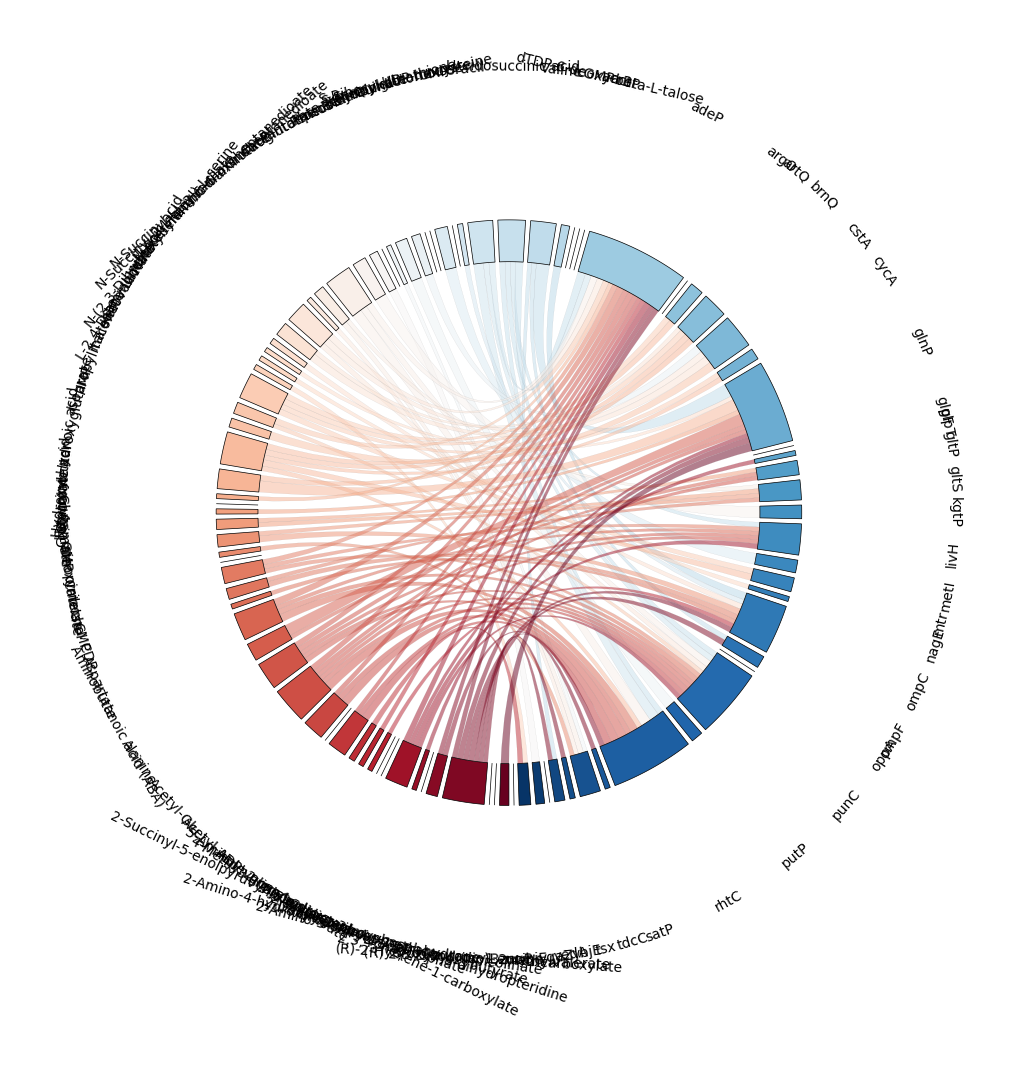

In [ ]:
circos2 = Circos.chord_diagram(wide_df.fillna(0),
                space = 1,
                start = -180,
                end = 180,
                r_lim = (60, 70),
                cmap = 'RdBu'

    )
# for sector in circos2.sectors:
#     print(sector.name)
#     sector.text(sector.name, size=8, color='k', r=105, rotation='vertical', ha='center', va='center')
#     for track in sector.tracks:
#         print(track)
fig2 = circos2.plotfig(figsize=(10,10))


In [ ]:
circos.links

AttributeError: 'Circos' object has no attribute 'links'

In [ ]:
met_changes.Total.max()

27

In [ ]:
sel_df.loc[sel_df.duplicated(subset=['Strain', 'ionMz'])]

,Strain,ionMz,Rel. abs. distance,Rel. distance,Mean abs. distance,Mean distance,MAE1,MAE2,Mean MAE,Strain 1,Strain 2,p-value rel,p-value abs,Metabolite,KEGG,All metabolite names


In [ ]:
edges = sel_df[['Strain', 'Metabolite', 'Rel. distance']].dropna().copy()
wide_df = edges.pivot(index='Metabolite', columns='Strain', values='Rel. distance')
wide_df.head()

Strain,acrB,actP,adeP,argO,artQ,brnQ,cstA,cycA,glnP,glpF,...,putP,rhtC,satP,tdcC,tsx,ybjE,yedA,ygaZ,yhjE,znuB
Metabolite,,,,,,,,,,,,,,,,,,,,,
(Iso)Leucine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.034978,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.019032,NaN,NaN
"(R) 2,3-Dihydroxy-3-methylvalerate",NaN,-5.34433,-6.518915,NaN,NaN,NaN,NaN,NaN,-13.065258,NaN,...,NaN,-8.386863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(R)-2-Hydroxybutane-1,2,4-tricarboxylate",NaN,NaN,NaN,-6.119485,NaN,-5.867243,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"2,3,4,5-Tetrahydrodipicolinate",NaN,NaN,6.635915,NaN,NaN,NaN,NaN,NaN,7.455470,NaN,...,NaN,NaN,5.593566,NaN,5.757761,5.563026,NaN,NaN,NaN,NaN
2-Amino-3-oxo-4-phosphonooxybutyrate,NaN,NaN,6.099883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,6.300220,NaN,NaN,NaN,NaN,NaN,-5.080848,NaN,NaN


In [ ]:
from pycirclize import Circos
import matplotlib.pyplot as plt
from collections import OrderedDict

edges = sel_df[['Strain', 'Metabolite', 'Rel. distance']].dropna().copy()
transporters = edges['Strain'].unique().tolist()
metabolites = edges['Metabolite'].unique().tolist()

# Ensure unique, ordered sector names and provide a dict (name -> size) to Circos
sector_names = list(OrderedDict.fromkeys(transporters + metabolites))
sectors = {name: 1 for name in sector_names}  # equal size for all sectors

circos = Circos(sectors=sectors)

for t in transporters:
    circos.sectors[t].color = "#1f77b4"  # blue for transporters
for m in metabolites:
    circos.sectors[m].color = "#ff7f0e"  # orange for metabolites

# for _, row in edges.iterrows():
#     color = "#C44E52" if row['Rel. distance'] < 0 else "#55A868"  # red for negative, green for positive
#     circos.link(row['Strain'], row['Metabolite'], color=color, linewidth=1)

fig = circos.plotfig()
plt.show()

TypeError: list indices must be integers or slices, not str

In [ ]:
circos.sectors['putP']

TypeError: list indices must be integers or slices, not str

# Track = 'Track01' (Parent Sector = '3',5'-Cyclic CMP')
# Size = 5.184923763105329 (0 - 5.184923763105329)
# Degree Size = 1.29 (24.05 - 25.34)
# Radius Size = 3.00 (97.00 - 100.00)



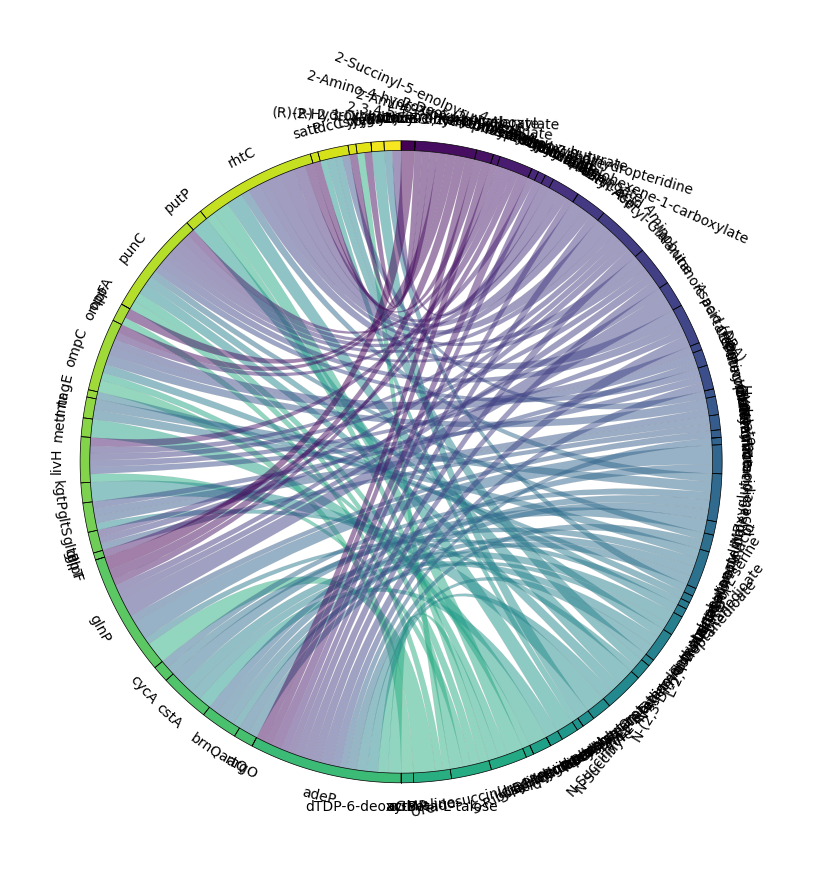

In [ ]:
circos = Circos.chord_diagram(wide_df.fillna(0)
                    )
fig = circos.plotfig()

In [ ]:
from pycirclize import Circos
import matplotlib.pyplot as plt

# Prepare edge list
edges = sel_df[['Strain', 'Metabolite']].dropna().copy()

# Get unique nodes
transporters = edges['Strain'].unique().tolist()
metabolites = edges['Metabolite'].unique().tolist()

# Create Circos object
circos = Circos(sectors=transporters + metabolites)

# Add sectors for transporters and metabolites
for t in transporters:
    circos.sectors[t].color = "#1f77b4"  # blue for transporters
for m in metabolites:
    circos.sectors[m].color = "#ff7f0e"  # orange for metabolites

# Add links
for _, row in edges.iterrows():
    circos.link(row['Strain'], row['Metabolite'], color="#888888", linewidth=1)

# Plot
fig = circos.plotfig()
plt.show()


AttributeError: 'list' object has no attribute 'items'

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
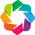

:Chord   [Strain,Metabolite]

In [ ]:
import holoviews as hv
from holoviews import opts
hv.extension('bokeh')

# Prepare edge list
edges = sel_df[['Strain', 'Metabolite']].dropna().copy()
edges['Metabolite'] = edges['Metabolite'].apply(lambda x: f"met_{hash(x)}")  # anonymize metabolite nodes

# Count links per transporter and metabolite
transporter_counts = edges['Strain'].value_counts()
metabolite_counts = edges['Metabolite'].value_counts()

# Sort transporters and metabolites by number of links
sorted_transporters = transporter_counts.index.tolist()
sorted_metabolites = metabolite_counts.index.tolist()

# Build node list: sorted transporters + sorted metabolites
nodes = sorted_transporters + sorted_metabolites[::-1]

# Only label transporters
node_labels = {n: n if n in sorted_transporters else '' for n in nodes}

# Build chord diagram
chord = hv.Chord((edges, hv.Dataset(pd.DataFrame({'name': nodes, 'label': [node_labels[n] for n in nodes]}), 'name')))
chord.opts(
    opts.Chord(
        labels='label',
        node_color='label',
        edge_color='Strain',
        cmap='Category20',
        label_text_font_size='10pt',
        node_size=10,
        width=600, height=600,
        title="Transporter–Metabolite Circular Chord Diagram (Sorted Metabolites)"
    )
)

In [ ]:
import plotly.graph_objects as go

# Drop missing values for clarity
df_sankey = sel_df.dropna(subset=['Strain', 'Metabolite'])

# Get unique nodes
transporters = df_sankey['Strain'].unique().tolist()
metabolites = df_sankey['Metabolite'].unique().tolist()
nodes = transporters + metabolites

# Map names to indices
node_indices = {name: i for i, name in enumerate(nodes)}

# Build source and target lists
sources = df_sankey['Strain'].map(node_indices).tolist()
targets = df_sankey['Metabolite'].map(node_indices).tolist()
values = [1]*len(sources)  # Each connection has equal weight

# Create Sankey diagram (chord-like)
fig = go.Figure(data=[go.Sankey(
    node=dict(label=nodes, pad=15, thickness=20),
    link=dict(source=sources, target=targets, value=values)
)])
fig.update_layout(title_text="Transporter–Metabolite Chord Diagram", font_size=10)
fig.show()

In [ ]:
import plotly.graph_objects as go

df_sankey = sel_df.dropna(subset=['Strain', 'Metabolite'])
transporters = df_sankey['Strain'].unique().tolist()
metabolites = df_sankey['Metabolite'].unique().tolist()
nodes = transporters + metabolites
node_indices = {name: i for i, name in enumerate(nodes)}
sources = df_sankey['Strain'].map(node_indices).tolist()
targets = df_sankey['Metabolite'].map(node_indices).tolist()
values = [1]*len(sources)

fig = go.Figure(data=[go.Sankey(
    node=dict(label=nodes),
    link=dict(source=sources, target=targets, value=values)
)])
fig.show()

Expression levels vs effect

In [ ]:
print(st.pearsonr(met_changest['Total'], met_changest['log10(Ribosome profiling)']))
notna = met_changest['log10(Mean protein number fraction)'].notna()
st.pearsonr(met_changest.loc[notna, 'Total'], met_changest.loc[notna, 'log10(Mean protein number fraction)'])
# plt.scatter(met_changest['Total'], met_changest['log10(Ribosome profiling)'])

PearsonRResult(statistic=np.float64(0.060627655905588974), pvalue=np.float64(0.636915828000703))


PearsonRResult(statistic=np.float64(0.1592577448030636), pvalue=np.float64(0.3076911586845205))

# Metabolite value

In [ ]:
value_fn = data_folder / 'Z_div/I_metabolite_values_big_screen.csv'
df_values = pd.read_csv(value_fn)
df_values['log10(Metabolite value)'] = np.log10(df_values['Metabolite value'])
kegg_to_logvalue = df_values.set_index('kegg_id')['log10(Metabolite value)'].to_dict()
kegg_to_value = df_values.set_index('kegg_id')['Metabolite value'].to_dict()

In [ ]:
for i, row in strain_changes.iterrows():
    values = [kegg_to_value.get(kegg, np.nan) for kegg in row['KEGG'].split(';')]
    logvalues = [kegg_to_logvalue.get(kegg, np.nan) for kegg in row['KEGG'].split(';')]
    strain_changes.at[i, 'log10(Metabolite value)'] = np.nanmean(logvalues)
    strain_changes.at[i, 'Metabolite value'] = np.nanmean(values)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2547272601.py:4: RuntimeWarning:

Mean of empty slice

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2547272601.py:5: RuntimeWarning:

Mean of empty slice

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2547272601.py:4: RuntimeWarning:

Mean of empty slice

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2547272601.py:5: RuntimeWarning:

Mean of empty slice



Pearson correlation: 0.073, p-value: 0.421


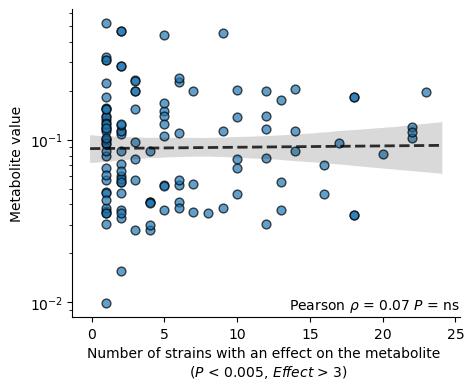

In [ ]:

fig, ax = plt.subplots(figsize=(5,4))
sns.scatterplot(data = strain_changes, x='Total', y='Metabolite value',
                            color='C0', ax = ax, edgecolor='k', s=40, alpha=0.7, 
                            linewidth=1)
rp = sns.regression._RegressionPlotter(strain_changes['Total'], strain_changes['log10(Metabolite value)'])

grid, yhat, err_bands = rp.fit_regression(ax=ax)
line, = ax.plot(grid, np.power(10, yhat), c = 'k', ls = '--', lw = 2, zorder=10, alpha = 0.8)
# plot error boundaries
ax.fill_between(
grid,
*[np.power(10, b) for b in err_bands],
facecolor=line.get_color(),
alpha=.15,
)
ax.set_yscale('log')
sns.despine()
plt.xlabel('Number of strains with an effect on the metabolite \n ($P$ < 0.005, $Effect$ > 3)')
# plt.ylabel(r'$\mathrm{log}_{10}$(Metabolite value [gDW/mmol])')

notnan = strain_changes['log10(Metabolite value)'].notna()
corr, pval = st.pearsonr(strain_changes.loc[notnan, 'Decrease'], strain_changes.loc[notnan, 'log10(Metabolite value)'])
print(f"Pearson correlation: {corr:.3f}, p-value: {pval:.3g}")
ax.text(1, 0.01, f'Pearson $ρ$ = {corr:.2f} $P$ = ns', transform=ax.transAxes, va = 'bottom', ha='right')
plt.savefig(figure_folder / f'figure_5_number_of_strains_vs_metabolite_value_transporter_KO_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')
        # create regression plotter object with log’d Y values

# Auxotroph cocultures

In [ ]:

auxotroph_cfus_fn = data_folder / 'E_auxotroph_coculture_CFUs.csv'
cfu_df = pd.read_csv(auxotroph_cfus_fn, index_col=0)

In [ ]:
cfu_df.sort_values(by='Partner', inplace = True)

In [ ]:
partners

['brnQ', 'cstA', 'glnP', 'metI', 'mtr', 'proP', 'putP', 'tsx', 'yeaS', 'ygaZ']

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2596295767.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2596295767.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2596295767.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2596295767.py:21: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/2596295767.py:21: UserWarning:

set_ticklabels() should only be used with a fixed numb

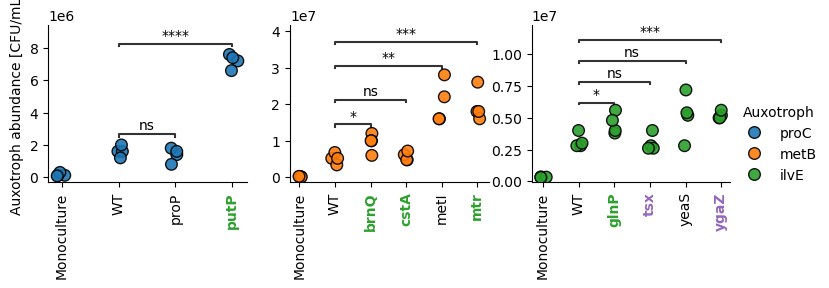

In [ ]:
g = sns.catplot(data = cfu_df, x = 'Partner', kind = 'strip', col = 'Auxotroph', y = 'Auxotroph abundance [CFU/mL]',
            hue = 'Auxotroph', col_wrap=3, sharex=False, sharey=False, height = 2.5, lw = 1, edgecolor='k', alpha=0.9, s=70)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')
g.set_titles('')#col_template = 'Auxotroph: {col_name}')
# ax.set_ylabel('Auxotroph abundance [CFU/mL]', fontsize = 7)
# plt.tight_layout()
from statannotations.Annotator import Annotator

for ax, auxotroph in zip(g.axes.flatten(), cfu_df['Auxotroph'].unique()):
    aux_idx = cfu_df['Auxotroph'] == auxotroph
    partners = [p for p in cfu_df.loc[aux_idx, 'Partner'].unique() if p not in ['WT', 'Monoculture']]
    pairs = [(p, 'WT') for p in partners]
    data_aux = cfu_df[cfu_df['Auxotroph'] == auxotroph]
    annotator = Annotator(ax, pairs, data=data_aux, x='Partner', y='Auxotroph abundance [CFU/mL]')
    annotator.configure(test='t-test_ind', text_format='star', loc='inside', verbose=0)
    # annotator.apply_and_annotate()
    annotator.apply_test(alternative = 'two-sided')
    annotator.annotate()
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_xlabel('')

    # Color xlabels for partners with effect > 3
    for tick in ax.get_xticklabels():
        partner = tick.get_text()
        # Find effect for this partner and auxotroph
        effect_row = sel_df[(sel_df['Strain'] == partner) & (sel_df['Metabolite'] == auxo_to_met.get(auxotroph, None))]
        if not effect_row.empty and effect_row['Rel. distance'].values[0] > 0:
            tick.set_color('C2')
            tick.set_fontweight('bold')
        elif not effect_row.empty and effect_row['Rel. distance'].values[0] < 0:
            tick.set_color('C4')
            tick.set_fontweight('bold')
        else:
            tick.set_color('black')

plt.savefig(figure_folder / f'figure_5_auxotroph_coculture_CFU_abundances.pdf', dpi=300, bbox_inches='tight')

In [ ]:
mean_cfu = cfu_df.groupby(['Partner', 'Auxotroph'])['Auxotroph abundance [CFU/mL]'].agg(['mean', 'std']).reset_index()

In [ ]:
auxo_to_met = {
    'proC': 'Proline',
    'metB': 'Methionine',
    'ilvE': '(Iso)Leucine',
}

In [ ]:
diff_data = []
for i, row in mean_cfu.iterrows():
    if row['Partner'] in ['Monoculture', 'WT']:
        continue
    # print(row)
    wt_idx = (mean_cfu['Partner'] == 'WT') & (mean_cfu['Auxotroph'] == row['Auxotroph'])
    diff = row['mean'] - mean_cfu.loc[wt_idx, 'mean'].values[0]
    std_wt = mean_cfu.loc[wt_idx, 'std'].values[0]
    pooled_std = np.sqrt(row['std']**2 + std_wt**2)

    # Get effect
    effect_idx = (dis_mz.Strain==row['Partner'])&(dis_mz.Metabolite == auxo_to_met[row['Auxotroph']])
    if effect_idx.sum() == 0:
        net_effect = np.nan
    else:
        net_effect = dis_mz.loc[effect_idx, 'Rel. distance'].values[0]
    diff_data.append([row['Auxotroph'], row['Partner'], diff, pooled_std, net_effect])

    print(f"{row['Auxotroph']} with {row['Partner']}: {row['mean']:.2e} ± {row['std']:.2e} CFU/mL")

metB with brnQ: 9.50e+06 ± 2.52e+06 CFU/mL
metB with cstA: 5.75e+06 ± 1.17e+06 CFU/mL
ilvE with glnP: 4.55e+06 ± 8.23e+05 CFU/mL
metB with metI: 2.05e+07 ± 5.74e+06 CFU/mL
metB with mtr: 1.95e+07 ± 4.43e+06 CFU/mL
proC with proP: 1.40e+06 ± 4.32e+05 CFU/mL
proC with putP: 7.20e+06 ± 4.32e+05 CFU/mL
ilvE with tsx: 3.00e+06 ± 6.73e+05 CFU/mL
ilvE with yeaS: 5.15e+06 ± 1.81e+06 CFU/mL
ilvE with ygaZ: 5.20e+06 ± 2.83e+05 CFU/mL


In [ ]:
diff_auxo = pd.DataFrame(diff_data, columns=['Auxotroph', 'Partner', 'Diff CFU', 'Diff CFU std', 'Net effect'])

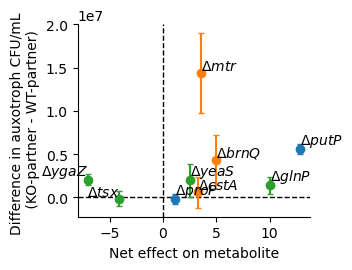

In [ ]:
fig, ax = plt.subplots(figsize=(3,2.5))
ax.axvline(0, color='k', ls='--', lw=1)
ax.axhline(0, color='k', ls='--', lw=1)
aux_to_color = {'proC': 'C0', 'metB': 'C1', 'ilvE': 'C2'}
for i, row in diff_auxo.iterrows():
    ax.errorbar(row['Net effect'], row['Diff CFU'], yerr=row['Diff CFU std'], 
    fmt='o', color=aux_to_color[row['Auxotroph']],
     capsize=2)
    ax.text(row['Net effect'], row['Diff CFU'], f'Δ${row['Partner']}$', fontsize=10, ha='right' if row['Net effect']<0 else 'left', va='bottom')
sns.despine()
plt.xlabel('Net effect on metabolite')
plt.ylabel('Difference in auxotroph CFU/mL \n (KO-partner - WT-partner)')
plt.savefig(figure_folder / f'figure_5_auxotroph_coculture_CFUs_vs_net_effect_{normalization}_norm_lam_{lam}.pdf', dpi=300, bbox_inches='tight')

In [ ]:
notnan = diff_auxo['Net effect'].notna()
st.pearsonr(diff_auxo.loc[notnan, 'Diff CFU'], diff_auxo.loc[notnan, 'Net effect'])

PearsonRResult(statistic=np.float64(0.26984453515893964), pvalue=np.float64(0.482550958177575))

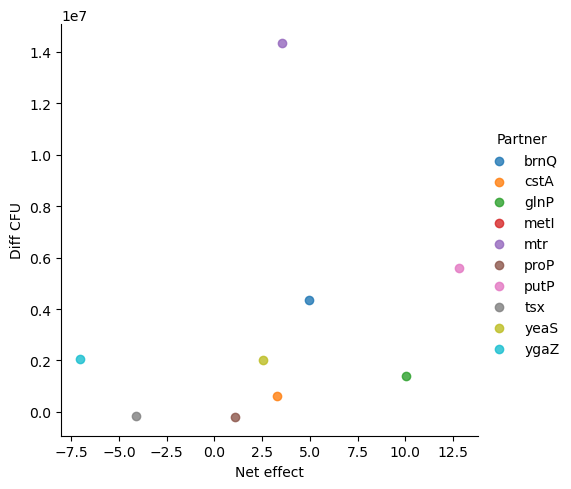

In [ ]:
sns.lmplot(data = diff_auxo, x='Net effect', y='Diff CFU', hue='Partner')

In [ ]:
diff_data = []
for auxotroph in cfu_df['Auxotroph'].unique():
    wt_mean = cfu_df.loc[(cfu_df.Partner == 'WT')&(cfu_df.Auxotroph == auxotroph), 'Auxotroph abundance [CFU/mL]'].mean()
    aux_data = cfu_df.loc[cfu_df.Auxotroph == auxotroph].copy()
    for i, row in aux_data.iterrows():
        if row['Partner'] in ['WT', 'Monoculture']:
            continue
        diff = row['Auxotroph abundance [CFU/mL]'] - wt_mean
        diff_data.append([row['Partner'], auxotroph, row['Well'], diff])
diff_df = pd.DataFrame(diff_data, columns=['Partner', 'Auxotroph', 'Well', 'Difference_vs_WT'])

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/1010816180.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/1010816180.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_84606/1010816180.py:4: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



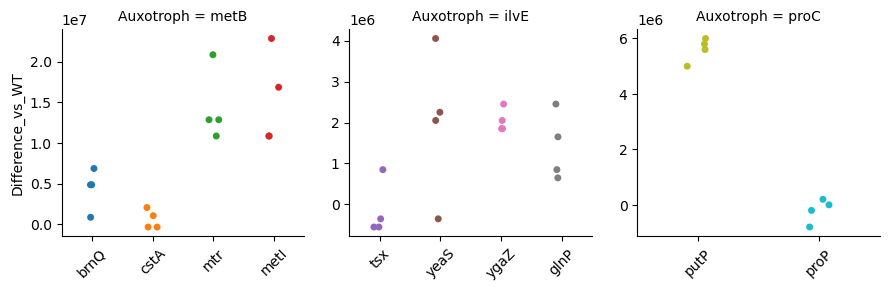

In [ ]:
g = sns.catplot(data = diff_df, x = 'Partner', kind = 'strip', col = 'Auxotroph', y = 'Difference_vs_WT',
            hue = 'Partner', col_wrap=3, sharex=False, sharey=False, height = 3)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')
# ax.set_ylabel('Auxotroph abundance [CFU/mL]', fontsize = 7)
# plt.tight_layout()

<BarContainer object of 4 artists>

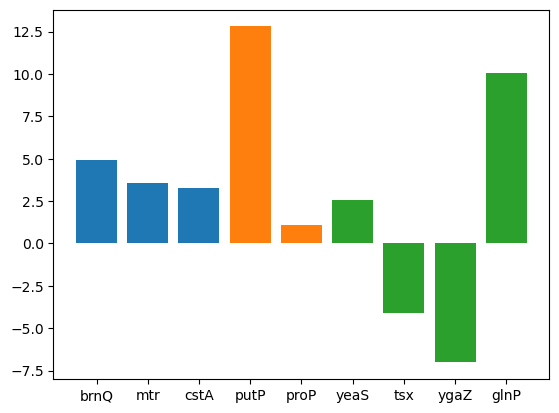

In [ ]:
idx_met = dis_mz.Strain.isin(['metI','mtr', 'cstA', 'brnQ'])& (dis_mz.Metabolite =='Methionine')
idx_pro = dis_mz.Strain.isin(['putP','proP']) & (dis_mz.Metabolite =='Proline')
idx_ile = dis_mz.Strain.isin(['tsx', 'yeaS', 'ygaZ', 'glnP']) & (dis_mz.Metabolite =='(Iso)Leucine')

plt.bar(x = dis_mz.loc[idx_met, 'Strain'], height = dis_mz.loc[idx_met,'Rel. distance'])
plt.bar(x = dis_mz.loc[idx_pro, 'Strain'], height = dis_mz.loc[idx_pro,'Rel. distance'])
plt.bar(x = dis_mz.loc[idx_ile, 'Strain'], height = dis_mz.loc[idx_ile,'Rel. distance'])

# Plot AUC vs AUC

## Get significance from timecurve comparisons

In [ ]:
strain_ionMz_to_pval = dis_w_mz.set_index(['Strain', 'ionMz'])['p-value rel'].to_dict()
strain_ionMz_to_distance = dis_w_mz.set_index(['Strain', 'ionMz'])['Rel. abs. distance'].to_dict()

NameError: name 'dis_w_mz' is not defined

In [ ]:
auc_df['Batch'] = auc_df['Batch-Tube'].apply(lambda x: x.split('-')[0])

In [ ]:
mean_auc = auc_df.groupby(['Batch', 'Strain', 'ionMz']).agg({'AUC Z-score (AUC OD)': ['mean', 'std']}).reset_index()
mean_auc.columns = ['Batch', 'Strain', 'ionMz', 'Mean AUC Z-score', 'STD AUC Z-score']  

In [ ]:
mean_auc['p-value rel'] = mean_auc.apply(lambda row: strain_ionMz_to_pval.get((row['Strain'], row['ionMz']), np.nan), axis=1)
# mean_auc['Significant'] = mean_auc['p-value rel'] < 0.01

# t-test based on AUC

In [ ]:
import scipy.stats as st

results = []
all_mZ_ions = auc_df['ionMz'].unique()
for strain in auc_df['Strain'].unique():
    if strain == 'WT':
        continue
    dfs = auc_df[auc_df['Strain'].isin([strain, 'WT'])]
    for ion in all_mZ_ions:
        dfi = dfs.loc[dfs['ionMz'] == ion]
        if dfi['Strain'].nunique() < 2:
            continue
        wt_values = dfi.loc[dfi['Strain'] == 'WT', 'AUC Z-score (AUC OD)'].values
        strain_values = dfi.loc[dfi['Strain'] == strain, 'AUC Z-score (AUC OD)'].values
        # Use t-test (or use st.mannwhitneyu for non-parametric)
        stat, pval = st.ttest_ind(strain_values, wt_values, equal_var=False, alternative='two-sided')
        results.append({'ionMz': ion, 'strain': strain, 'statistic': stat, 'pvalue': pval})
ttest_auc_df = pd.DataFrame(results)


In [ ]:

for strain in ttest_auc_df['strain'].unique():
    sidx = ttest_auc_df['strain'] == strain
    df_strain = ttest_auc_df[ttest_auc_df['strain'] == strain]
    pvals = ttest_auc_df.loc[sidx, 'pvalue'].values
    reject, pvals_corrected, _, _ = multipletests(pvals,alpha = 0.01, method='fdr_bh')
    ttest_auc_df.loc[sidx, 'pvalue_adj'] = pvals_corrected

# # Correct p-values for multiple testing (FDR)
# ttest_auc_df['p_adj'] = multipletests(ttest_auc_df['pvalue'], method='fdr_bh')[1]


In [ ]:
strain_ionMz_to_pval_auc = ttest_auc_df.set_index(['strain', 'ionMz'])['pvalue_adj'].to_dict()



In [ ]:
strains = sorted([x for x in mean_auc.Strain.unique() if x!= 'WT'])
fig, axes = plt.subplots(21, 3, figsize=(12,30))
axes = axes.flatten()
for j, strain in enumerate(strains):
    batch = mean_auc.loc[mean_auc.Strain == strain, 'Batch'].values[0]
    dfi = mean_auc.loc[mean_auc.Strain.isin([strain, 'WT']) & (mean_auc.Batch == batch)]
    
    dfi_wide = dfi.pivot(index='ionMz', columns='Strain', values=['Mean AUC Z-score', 'STD AUC Z-score'])
    dfi_wide.columns = [f'{stat}_{s}' for stat, s in dfi_wide.columns]
    dfi_wide = dfi_wide.reset_index()
    for i, row in dfi_wide.iterrows():
        dfi_wide.loc[i, 'Significance'] = (strain_ionMz_to_pval[(strain, row['ionMz'])] < max_pval) and (strain_ionMz_to_distance[(strain, row['ionMz'])] > min_effect)
        dfi_wide.loc[i, 'p-value'] = strain_ionMz_to_pval[(strain, row['ionMz'])]
        dfi_wide.loc[i, 'p-value auc'] = strain_ionMz_to_pval_auc.get((strain, row['ionMz']), np.nan)
    ax = axes[j]
    for sgn in [False, True]:
        subset = dfi_wide[dfi_wide['Significance'] == sgn]
        ax.errorbar(
            x = subset['Mean AUC Z-score_WT'],
            y = subset[f'Mean AUC Z-score_{strain}'],
            xerr=subset['STD AUC Z-score_WT'],
            yerr=subset[f'STD AUC Z-score_{strain}'],
            alpha=0.7 if sgn else 0.2,
            fmt = 'o',
            c = 'C0' if sgn else 'gray',
            mec = 'C0' if sgn else 'gray',
            mfc = 'C0' if sgn else 'gray',
            label='Significant' if sgn else 'Not significant'
        )
    xrange = [dfi_wide['Mean AUC Z-score_WT'].min()-20, dfi_wide['Mean AUC Z-score_WT'].max()+20]
    yrange = [dfi_wide[f'Mean AUC Z-score_{strain}'].min()-20, dfi_wide[f'Mean AUC Z-score_{strain}'].max()+20]
    ax.set_xlim(xrange)
    ax.set_ylim(yrange)
    ax.set_title(f'Δ${strain}$')
    ax.plot([-100,100],[-100,100], ls = '--', c = 'gray', lw = 0.8, zorder = 0)
    ax.axvline(0, ls = '--', c = 'gray', lw = 0.8, zorder = 0)
    ax.axhline(0, ls = '--', c = 'gray', lw = 0.8, zorder = 0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
sns.despine()
plt.tight_layout()
plt.savefig(figure_folder / 'auc_comparision_all_keio_strains.png', dpi=300)

NameError: name 'mean_auc' is not defined

# Plot timeseries

In [ ]:
timeseries_plots_folder = figure_folder / 'timeseries_plots'
timeseries_plots_folder.mkdir(exist_ok=True, parents=True)



In [ ]:
dis_mz.drop_duplicates(subset=['Strain', 'ionMz'], inplace=True)

# Plot to 40


In [ ]:
# dis_mz['Kept names'] = dis_mz.ionMz.map(df_ionMz.set_index('ionMz')['Kept names'].to_dict())


In [ ]:
sel_idx = (dis_mz['Rel. abs. distance'] > 3)&(dis_mz['p-value rel'] < 0.005)

KeyError: 'Kept names'

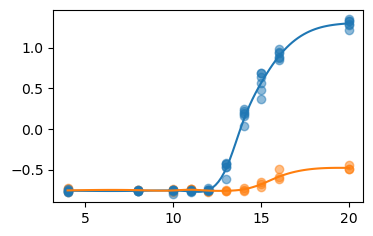

In [ ]:
xval = 'Hours'
yval = 'Median Z-score'
ystd = 'Z-score std'

for i, row in dis_mz.loc[sel_idx].sort_values(by=['Rel. abs. distance'], ascending=False).head(40).iterrows():
    batch = df.loc[df.Strain == row['Strain'], 'Batch'].values[0]
    data = df.loc[(df.ionMz == row['ionMz'])&(df.Strain.isin(['WT', row['Strain']]))&(df['Batch'] == batch)].copy()
    
    ionMz = row['ionMz']
    strain = row['Strain']
    is_duplicated = data[xval].duplicated()
    if np.any(is_duplicated):
        data.loc[is_duplicated, xval] += np.random.normal(0, 1e-3, size=is_duplicated.sum())
    data.sort_values(by=xval, inplace=True)
    x = data.loc[data.Strain == strain, xval].values
    y = data.loc[data.Strain == strain, yval].values
    y_std = data.loc[data.Strain == strain, ystd].values

    xwt = data.loc[data.Strain == 'WT', xval].values
    ywt = data.loc[data.Strain == 'WT', yval].values
    ywt_std = data.loc[data.Strain == 'WT', ystd].values

    spline = make_smoothing_spline(x, y, w = 1/y_std, lam = lam)
    spline_wt = make_smoothing_spline(xwt, ywt, w = 1/ywt_std, lam = lam)

    x_common = np.linspace(max(x.min(), xwt.min()), min(x.max(), xwt.max()), 100, endpoint=True)

    fig, ax = plt.subplots(1, figsize=(4,2.5))
    ax.plot(x_common, spline_wt(x_common), label='WT', color='C0')
    ax.plot(x_common, spline(x_common), label=f'Δ{strain}', color='C1')

    ax.scatter(x, y, color='C1', alpha=0.5)
    ax.scatter(xwt, ywt, color='C0', alpha=0.5)
    ax.set_title(f'Δ${strain}$ - m/z = {ionMz:.3f} \n {row['Kept names']} ({row['Mapped KEGG'].replace(";"," / ")})', size = 10)
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Median Z-score')
    sns.despine()
    # plt.tight_layout()
    # plt.subplots_adjust(left=0.5, right=0.95)
    ax.legend()
    plt.savefig(timeseries_plots_folder / f'timeseries_{strain}_metabolite_{row["Metabolite"]}.png', dpi=300, bbox_inches='tight')
    plt.savefig(timeseries_plots_folder / f'timeseries_{strain}_metabolite_{row["Metabolite"]}.pdf', dpi=300)
    
    plt.show()



# Plot bar charts

In [ ]:
sel_df = dis_mz.loc[sel_idx].copy()

In [ ]:
all_strains = dis_mz['Strain'].unique()
N_changed_mets = sel_df.groupby('Strain')['Kept names'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
N_changed_mets_neg = sel_df.loc[sel_df['Rel. distance'] < 0].groupby('Strain')['Kept names'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)
N_changed_mets_pos = sel_df.loc[sel_df['Rel. distance'] > 0].groupby('Strain')['Kept names'].count().reindex(all_strains, fill_value=0).sort_values(ascending=False)

In [ ]:
met_changes = pd.merge(N_changed_mets_neg, N_changed_mets_pos, left_index=True, right_index=True, how='outer')
met_changes.columns = ['Decrease', 'Increase']
met_changes = met_changes.reset_index()
met_changes.dropna(inplace=True)

In [ ]:
met_changes['Total'] = met_changes['Decrease'] + met_changes['Increase']

In [ ]:
met_changes.sort_values(by='Total', ascending=False)

,Strain,Decrease,Increase,Total
2,adeP,24,36,60
41,punC,21,28,49
19,glnP,26,21,47
60,ygaZ,31,7,38
46,rhtC,12,23,35
...,...,...,...,...
12,dcuA,0,0,0
45,rhtB,0,0,0
25,hisQ,0,0,0
34,nupC,0,0,0


In [ ]:
met_changesL = met_changes.reset_index().melt(id_vars='Strain', var_name='Release', 
value_name='Number of changed metabolites', value_vars=['Increase', 'Decrease'])
met_changesL['Total'] = met_changesL.Strain.map(met_changes.set_index('Strain')['Total'].to_dict())

In [ ]:
met_changes.sort_values(by=['Total', 'Strain'], ascending=[False, True], inplace=True)

In [ ]:
ax.get_xticklabels()[0]

Text(0, 0, "ΔText(0, 0, 'adeP')")

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_2719/3284901492.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'Δ${lbl}$' for lbl in met_changes['Strain']], rotation=90)


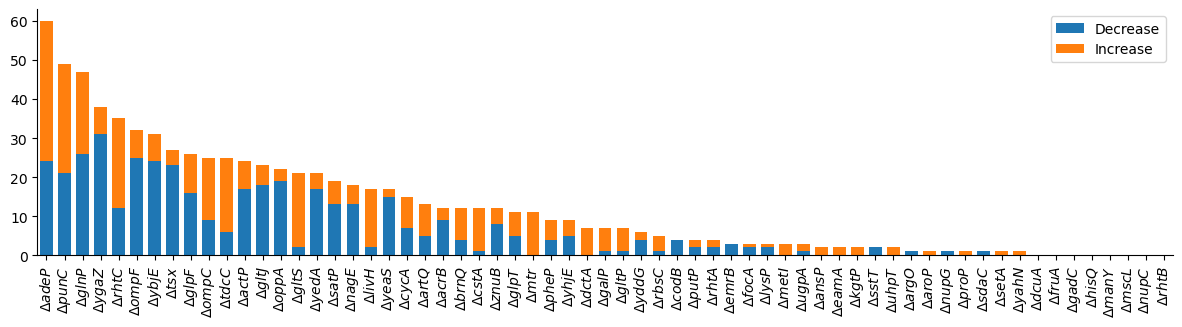

In [ ]:
fig, ax = plt.subplots(figsize = (12,3))
bar_width = 0.7  # Adjust this value for wider/narrower bars

ax.bar(met_changes['Strain'], height = met_changes['Decrease'], width=bar_width, label='Decrease')
ax.bar(met_changes['Strain'], height =  met_changes['Increase'], bottom=met_changes['Decrease'], width=bar_width, label='Increase')
plt.xlim(-0.5, len(met_changes['Strain'])-0.5)
ax.legend()
plt.tight_layout()
ax.set_xticklabels([f'Δ${lbl}$' for lbl in met_changes['Strain']], rotation=90)
# ax.set_ylabel('Number of affected metabolites \n (Effect > %s and p-value < %s)'%(rel_dis_limit, p_val_limit))
sns.despine()
plt.show()


# Histograms

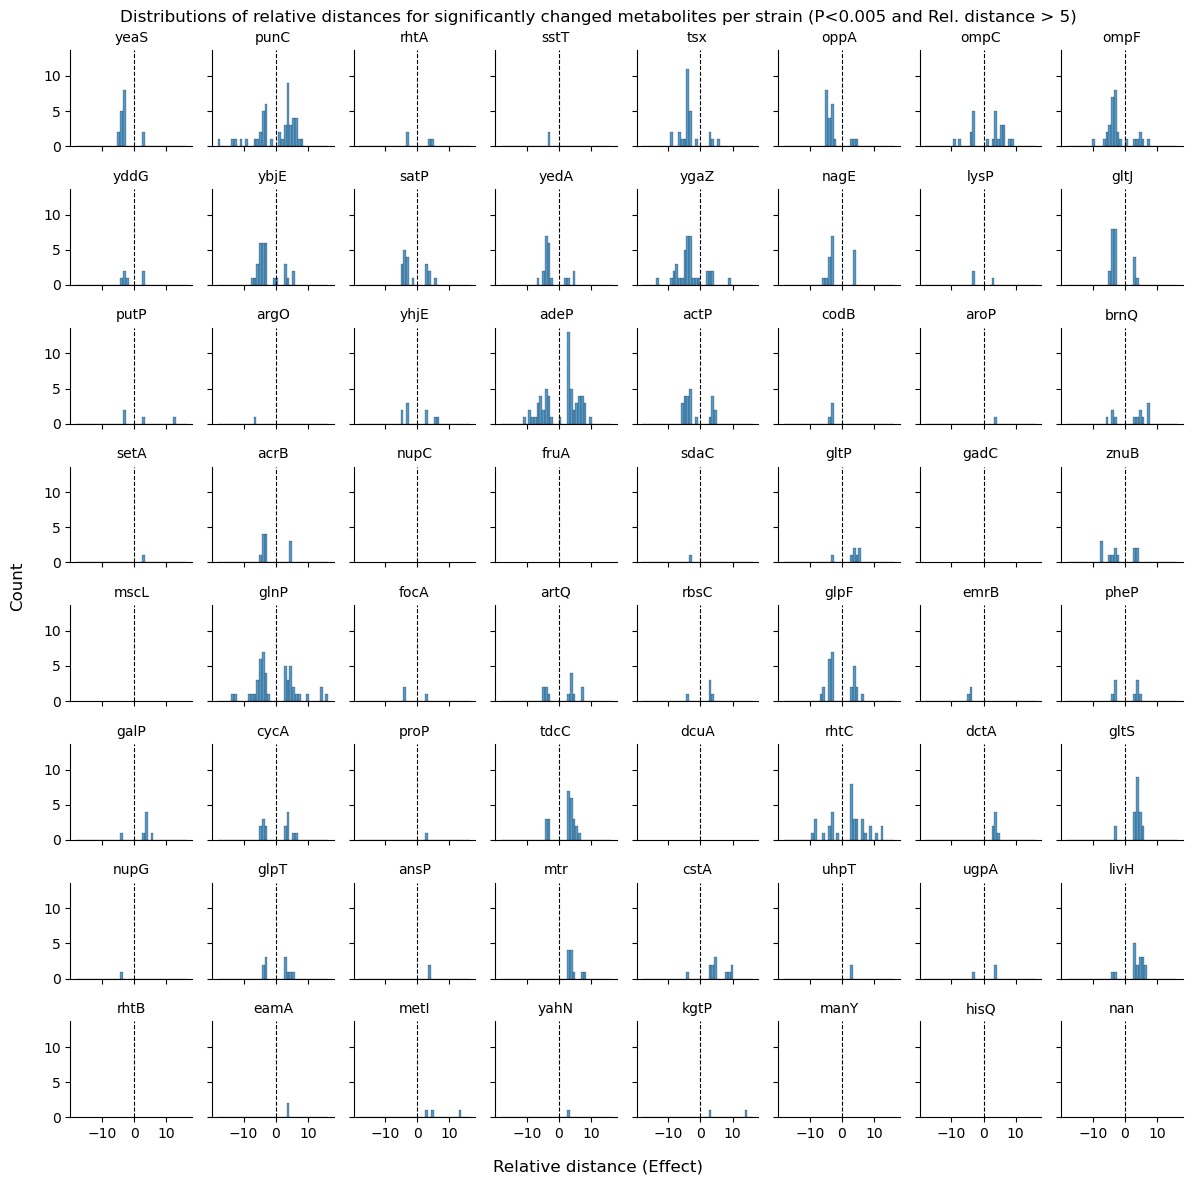

In [ ]:
g = sns.displot(sel_df,  x='Rel. distance', col = 'Strain', 
                col_wrap=8, bins = 40, col_order=met_changes.index, height = 1.5)#, hue = 'Batch')
for ax in g.axes.flatten():
    ax.axvline(0, c = 'k', ls = '--', lw = 0.8)
    ax.set_xlabel('')
    ax.set_ylabel('')
g.set_titles(col_template = '{col_name}', size = 10)
g.fig.suptitle('Distributions of relative distances for significantly changed metabolites per strain (P<0.005 and Rel. distance > 5)')
g.fig.supxlabel(r'Relative distance (Effect)', y=0.01, fontsize=12)
g.fig.supylabel('Count', x=0.01, fontsize=12)
    # ax.annotate(0.05, 0.05, )
# plt.yscale('log')
plt.tight_layout()

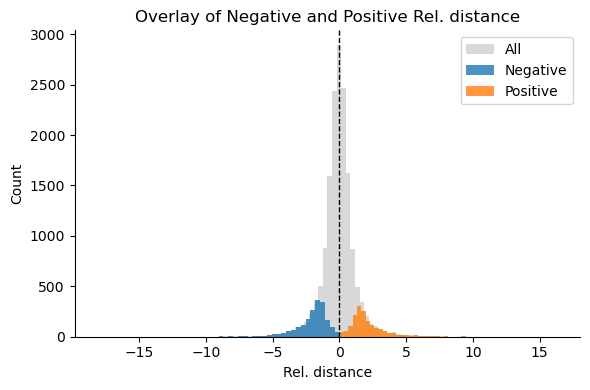

In [ ]:
plt.figure(figsize=(6, 4))
data = dis_mz.loc[dis_mz['p-value rel'] < 0.005, 'Rel. distance']

plt.hist(dis_mz['Rel. distance'], bins=100, alpha=0.3, color='grey', label='All')
plt.hist(data[data < 0], bins=50, alpha=0.8, color='C0', label='Negative')
plt.hist(data[data > 0], bins=50, alpha=0.8, color='C1', label='Positive')

plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel('Rel. distance')
plt.ylabel('Count')
plt.legend()
# plt.yscale('log')
plt.title('Overlay of Negative and Positive Rel. distance')
plt.tight_layout()
sns.despine()
plt.show()